Setup Keras Environment

# Deep Mammo-Scan

## Environment Setup

In [ ]:
import os
from pathlib import Path
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc


from keras import layers
from keras import regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def clear_keras():
    keras.backend.clear_session()
    gc.collect()

In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/Databases/cbis_ddsm_processed")

DATA_DIR_FULL = DATA_ROOT / "cbis_ddsm_processed_full"
DATA_DIR_ROI = DATA_ROOT / "cbis_ddsm_processed_roi"

DATA_DIR_FULL_TEST = DATA_DIR_FULL / "test"
DATA_DIR_FULL_TRAIN = DATA_DIR_FULL / "train"
DATA_DIR_ROI_TEST = DATA_DIR_ROI / "test"
DATA_DIR_ROI_TRAIN = DATA_DIR_ROI / "train"





# Defining the Task

**What am I trying to predict?**

This project is a binary classification task: given a mammogram image (or the cropped region of interest within it), predict whether the abnormality shown is **benign** or **malignant**.



**What data do I have, and can it answer the questions?**

I am using the CBIS-DDSM dataset, which provides mammogram images along with pathology labels that have already been confirmed by radiologists. Since the labels come from real clinical diagnoses, the data does contain the information needed to learn this task. The main limitation is the size of the dataset, which is small compared to what's typically used to train large CNNs from scratch, which is part of why transfer learning is used here rather than training a new architecture from the ground up.



### Understanding the Data

```
cbis_ddsm_processed
├───cbis_ddsm_processed_full
│   ├───test
│   │   ├───benign
│   │   └───malignant
│   └───train
│       ├───benign
│       └───malignant
└───cbis_ddsm_processed_roi
    ├───test
    │   ├───benign
    │   └───malignant
    └───train
        ├───benign
        └───malignant
```



**Example file names**
```
Calc_P_00007_LEFT_CC_1.png
Calc_P_00007_LEFT_MLO_1.png
Calc_P_00008_LEFT_CC_1.png
Calc_P_00008_LEFT_CC_2.png
Calc_P_00008_LEFT_CC_3.png
Calc_P_00008_LEFT_MLO_1.png
Calc_P_00008_LEFT_MLO_2.png
Calc_P_00008_LEFT_MLO_3.png
Calc_P_00008_RIGHT_CC_1.png
Calc_P_00008_RIGHT_CC_2.png
Calc_P_00008_RIGHT_CC_3.png
Calc_P_00008_RIGHT_CC_4.png
Calc_P_00008_RIGHT_CC_5.png
Calc_P_00008_RIGHT_MLO_1.png
Calc_P_00008_RIGHT_MLO_2.png
Calc_P_00008_RIGHT_MLO_3.png
Calc_P_00008_RIGHT_MLO_4.png
Calc_P_00008_RIGHT_MLO_5.png
Calc_P_00010_LEFT_CC_1.png
Calc_P_00010_LEFT_MLO_1.png
```




**File naming convention**

LesionType_PatientId_BreastSide_ImageView_AbnormalityId

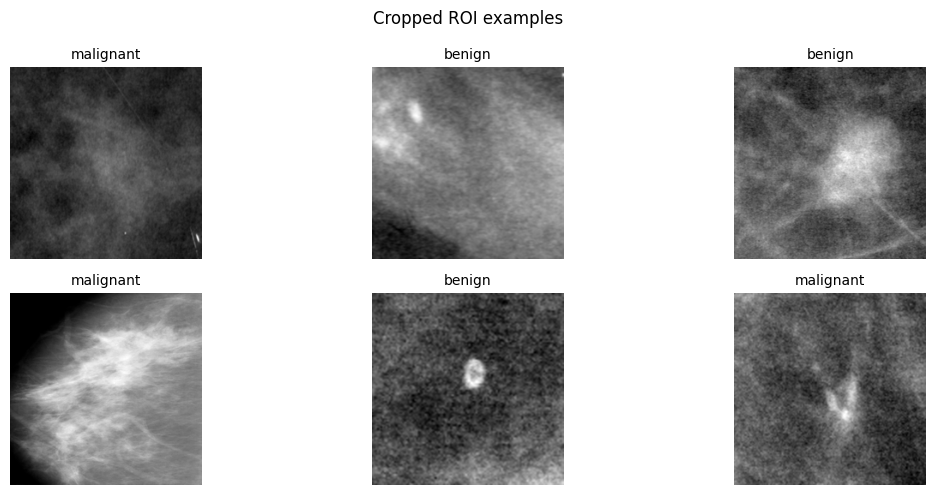

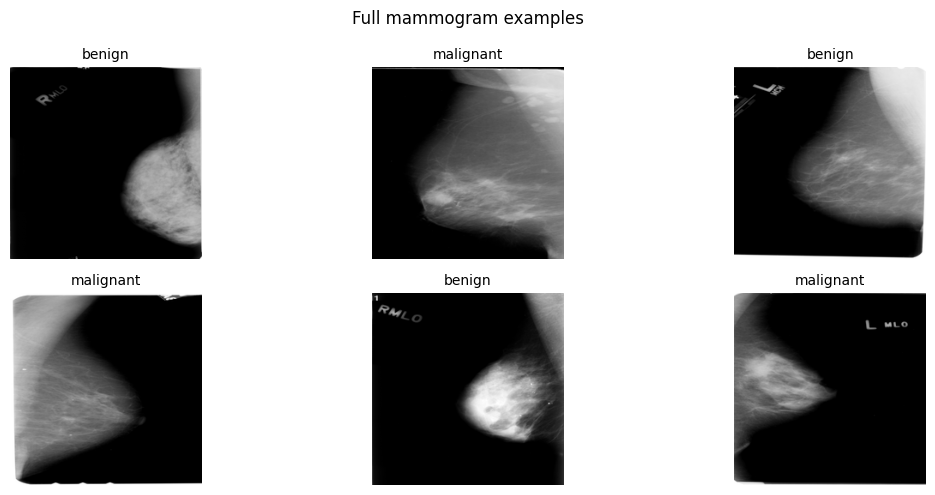

In [ ]:
import random

def show_examples(output_root, title, n=6):
    # Show n random example images from a processed dataset folder.

    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 5))
    axes = axes.flatten()

    # Gather a few images from each class so both are represented
    image_paths = []
    for label in ["benign", "malignant"]:
        folder = output_root / "train" / label
        files = list(folder.glob("*.png"))
        random.shuffle(files)
        image_paths.extend([(f, label) for f in files[: n // 2]])

    random.shuffle(image_paths)

    for ax, (path, label) in zip(axes, image_paths):
        img = tf.keras.utils.load_img(path, color_mode="grayscale")
        ax.imshow(img, cmap = "gray")
        ax.set_title(label, fontsize=10)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(DATA_DIR_ROI, "Cropped ROI examples")
show_examples(DATA_DIR_FULL, "Full mammogram examples")


Full Image Dataset
Train - Benign:     1347
Train - Malignant:  1111
Test  - Benign:     233
Test  - Malignant:  166

ROI Dataset
Train - Benign:     1683
Train - Malignant:  1181
Test  - Benign:     330
Test  - Malignant:  217


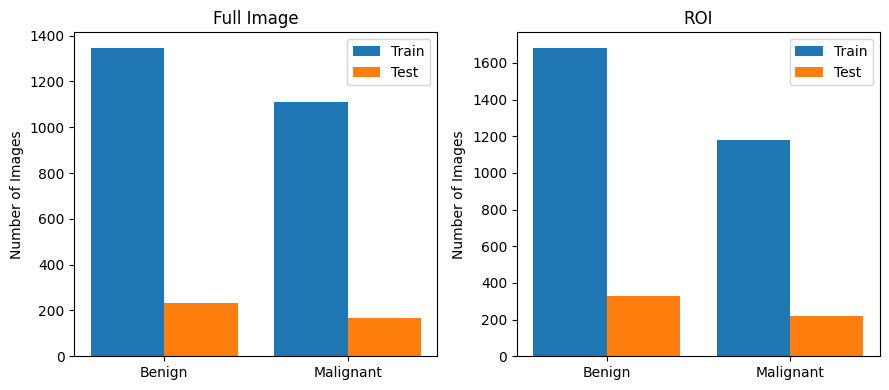

In [ ]:
datasets = {"Full Image": DATA_DIR_FULL, "ROI": DATA_DIR_ROI}

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (name, root) in zip(axes, datasets.items()):

    train = [
        len(list((root / "train" / "benign").iterdir())),
        len(list((root / "train" / "malignant").iterdir()))
    ]

    test = [
        len(list((root / "test" / "benign").iterdir())),
        len(list((root / "test" / "malignant").iterdir()))
    ]

    x = [0, 1]

    ax.bar([i - 0.2 for i in x], train, 0.4, label="Train")
    ax.bar([i + 0.2 for i in x], test, 0.4, label="Test")

    ax.set_xticks(x)
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_title(name)
    ax.set_ylabel("Number of Images")
    ax.legend()

    # Print dataset counts
    print(f"\n{name} Dataset")
    print(f"Train - Benign:     {train[0]}")
    print(f"Train - Malignant:  {train[1]}")
    print(f"Test  - Benign:     {test[0]}")
    print(f"Test  - Malignant:  {test[1]}")

plt.tight_layout()
plt.show()




Class Imbalance

Both the Full Image and ROI datasets exhibit a moderate class imbalance, with benign images outnumbering malignant images in both the training and test sets.
Full Image Dataset

The training set contains:

- 1,347 benign images (54.8%)

- 1,111 malignant images (45.2%)


The test set contains:

- 233 benign images (58.4%)

- 166 malignant images (41.6%)


ROI Dataset

The training set contains:

- 1,683 benign images (58.8%)

- 1,181 malignant images (41.2%)



The test set contains:

- 330 benign images (60.3%)

- 217 malignant images (39.7%)


Overall, the data contains a slight to moderate level of class imbalance, with the extreme being 60.3% to 39.7%

This provides a reasonable justification for experimenting with class weighting.

### Choosing a measure of success

Because this is a medical screening problem, accuracy alone isn't enough to judge whether the model is actually useful. A model that just predicts "benign" most of the time could still score reasonably high on accuracy while missing most of the cancers. For that reason, the model will be judged mainly on:

- **Sensitivity (recall)**, of all the truly malignant cases, how many did the model catch? This is the most important metric here, since a missed malignant case (a false negative) is far more costly than a false alarm.
- **Specificity**, of all the truly benign cases, how many did the model correctly clear?
- **False negative rate**, including false negatives per 1,000 screens, to express missed cancers in a way that's directly comparable to clinical benchmarks.

Accuracy, precision, F1 score, and AUC will still be tracked as supporting metrics, and the ROC curve and confusion matrix will be used to look at the full trade-off between sensitivity and specificity rather than relying on a single number.



**What does "good enough" look like?**

The model's sensitivity and specificity will be compared against the BCSC national screening benchmarks (87.4% sensitivity, 92.2% specificity), which represent how real radiologists perform on average, giving a meaningful target rather than an arbitrary one.

**What are the constraints?**

The model should be computationally efficient enough to be plausible for deployment in a resource-constrained setting. This is one reason MobileNetV2 was selected over more computationally demanding architectures. Training and inference times on CPU and TPU will therefore be recorded alongside classification performance to assess the computational cost of each approach.

# Developing the Model

## Data Preparation


In [ ]:

IMG_SIZE = (224, 224)

CLASS_NAMES = [
    "benign",
    "malignant"
]

CLASS_TO_LABEL = {
    "benign": 0,
    "malignant": 1
}

LESION_TYPES = [
    "Calc",
    "Mass"
]
batch_size = 32



In [ ]:
def get_lesion_type(filepath):
    """
    Extract lesion type from CBIS-DDSM filename.

    Examples:
        Calc_P_00007_LEFT_CC_1.png
            -> Calc

        Mass_P_00007_LEFT_MLO_1.png
            -> Mass
    """

    parts = Path(filepath).stem.split("_")

    if len(parts) < 5:
        raise ValueError(
            f"Unexpected filename format: "
            f"{Path(filepath).name}"
        )

    lesion_type = parts[0]

    if lesion_type not in LESION_TYPES:
        raise ValueError(
            f"Unknown lesion type '{lesion_type}' "
            f"in file: {Path(filepath).name}"
        )

    return lesion_type

def get_patient_id(filepath):
    """
    Extract patient ID from CBIS-DDSM filename.

    Examples:
        Calc_P_00007_LEFT_CC.png
        -> P_00007

        Calc_P_00007_LEFT_CC_1.png
        -> P_00007
    """

    parts = Path(filepath).stem.split("_")

    if len(parts) < 5:
        raise ValueError(
            f"Unexpected filename format: {Path(filepath).name}"
        )

    return f"{parts[1]}_{parts[2]}"


def get_breast_side(filepath):
    """
    Extract breast laterality.

    Example:
        Calc_P_00007_LEFT_CC.png
        -> LEFT
    """

    parts = Path(filepath).stem.split("_")

    if len(parts) < 5:
        raise ValueError(
            f"Unexpected filename format: {Path(filepath).name}"
        )

    return parts[3]


def get_view(filepath):
    """
    Extract mammogram view.

    Example:
        Calc_P_00007_LEFT_CC.png
        -> CC
    """

    parts = Path(filepath).stem.split("_")

    if len(parts) < 5:
        raise ValueError(
            f"Unexpected filename format: {Path(filepath).name}"
        )

    return parts[4]


def get_abnormality_id(filepath):
    """
    Extract abnormality ID if present.

    Examples:
        Calc_P_00007_LEFT_CC.png
        -> None

        Calc_P_00007_LEFT_CC_1.png
        -> 1
    """

    parts = Path(filepath).stem.split("_")

    if len(parts) >= 6:
        return parts[5]

    return None


def get_lesion_id(filepath):
    """
    Construct a lesion ID when an abnormality ID exists.

    If no abnormality ID is present, use:
        patient + breast side + view

    NOTE:
    This function is not used for train/validation splitting.
    Patient ID is the grouping variable for splitting.
    """

    patient_id = get_patient_id(filepath)
    side = get_breast_side(filepath)
    abnormality_id = get_abnormality_id(filepath)

    if abnormality_id is not None:
        return f"{patient_id}_{side}_{abnormality_id}"

    return f"{patient_id}_{side}_{get_view(filepath)}"


def get_image_paths_labels_groups(directory):
    """
    Load images while preserving the individual image label.

    Returns:
        image_paths
        labels
        group (patient id)

    patient_ids to group by patient for train/validation splitting.
    """

    image_paths = []
    labels = []
    group = []

    for class_name in CLASS_NAMES:

        class_dir = directory / class_name
        label = CLASS_TO_LABEL[class_name]

        for filepath in sorted(
            class_dir.rglob("*.png")
        ):

            image_paths.append(str(filepath))

            # Preserve the label of THIS IMAGE.
            labels.append(label)

            # Used only for train/validation splitting.
            group.append(
                get_patient_id(filepath)
            )

    return (
        np.array(image_paths),
        np.array(labels, dtype=np.int32),
        np.array(group)
    )


### Normalize and Vectorize Image

In [ ]:
def load_and_preprocess_image(filepath, label):
    # Read PNG from disk
    image_bytes = tf.io.read_file(filepath)

    # Decode as RGB
    image = tf.image.decode_png(
        image_bytes,
        channels=3
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(image, tf.float32)

    # MobileNetV2 preprocessing
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


In [ ]:
def create_dataset(
    image_paths,
    labels,
    batch_size=batch_size,
    shuffle=False,
    training=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
    else:
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)

    return dataset


In [ ]:
full_train_paths, y_full, full_groups = (
    get_image_paths_labels_groups(DATA_DIR_FULL_TRAIN)
)


roi_train_paths, y_roi, roi_groups = (
    get_image_paths_labels_groups(DATA_DIR_ROI_TRAIN)
)

full_test_paths, y_full_test, full_test_groups = (
    get_image_paths_labels_groups(DATA_DIR_FULL_TEST)
)

roi_test_paths, y_roi_test, roi_test_groups = (
    get_image_paths_labels_groups(DATA_DIR_ROI_TEST)
)


In [ ]:
for p in roi_train_paths[:10]:
    print(Path(p).name)


Calc_P_00007_LEFT_CC_1.png
Calc_P_00007_LEFT_MLO_1.png
Calc_P_00008_LEFT_CC_1.png
Calc_P_00008_LEFT_CC_2.png
Calc_P_00008_LEFT_CC_3.png
Calc_P_00008_LEFT_MLO_1.png
Calc_P_00008_LEFT_MLO_2.png
Calc_P_00008_LEFT_MLO_3.png
Calc_P_00008_RIGHT_CC_1.png
Calc_P_00008_RIGHT_CC_2.png


In [ ]:
BATCH_SIZE = 32

# full_train_ds = create_dataset(
#     full_train_paths,
#     y_full,
#     batch_size=BATCH_SIZE,
#     shuffle=True
# )

# full_test_ds = create_dataset(
#     full_test_paths,
#     y_full_test,
#     batch_size=BATCH_SIZE,
#     shuffle=False
# )

# roi_train_ds = create_dataset(
#     roi_train_paths,
#     y_roi,
#     batch_size=BATCH_SIZE,
#     shuffle=True
# )

# roi_test_ds = create_dataset(
#     roi_test_paths,
#     y_roi_test,
#     batch_size=BATCH_SIZE,
#     shuffle=False
# )


### Dataset Check

In [ ]:
print("\nSTREAMING / PREPROCESSING CHECK")
print("=" * 50)

BATCH_SIZE = 32

full_train_ds = create_dataset(
    full_train_paths,
    y_full,
    batch_size=BATCH_SIZE,
    shuffle=True
)

images, labels = next(iter(full_train_ds))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

print(
    "Batch image range:",
    tf.reduce_min(images).numpy(),
    "to",
    tf.reduce_max(images).numpy()
)

print(
    "Batch labels:",
    np.unique(labels.numpy())
)



STREAMING / PREPROCESSING CHECK
Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch image range: -1.0 to 1.0
Batch labels: [0 1]


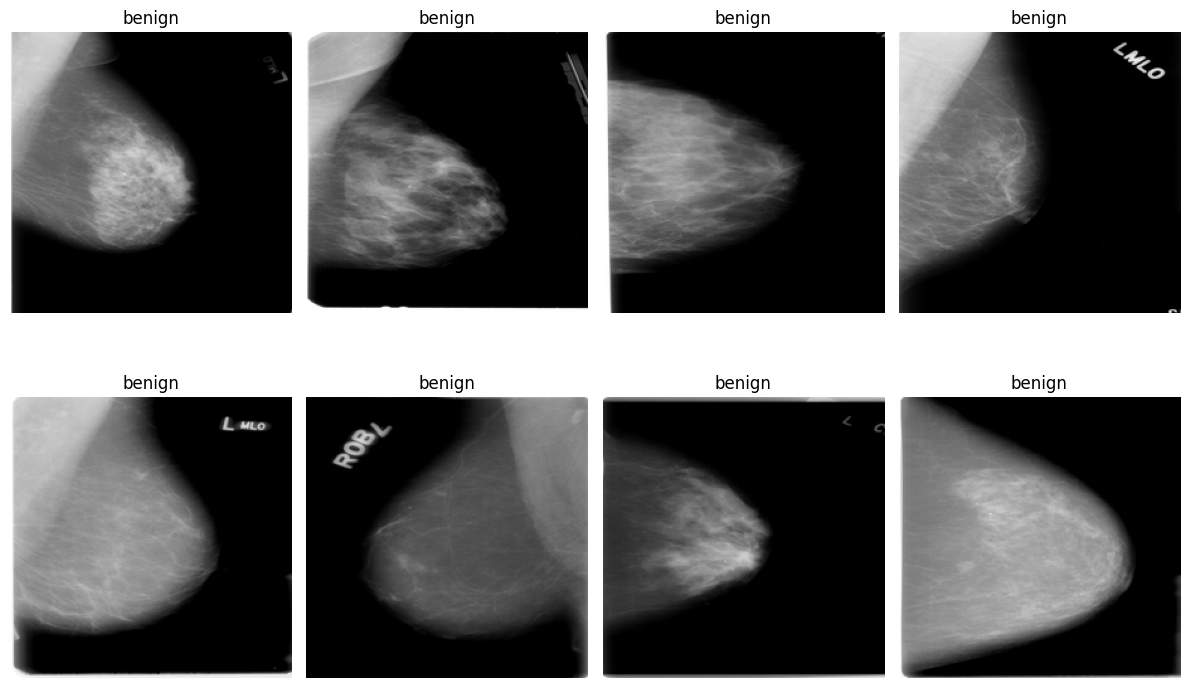

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(8):

    image = images[i].numpy()

    # MobileNetV2 preprocessing maps [0, 255] → [-1, 1].
    # Convert back to [0, 1] for displaying.
    image = (image + 1.0) / 2.0

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(
        "malignant" if labels[i].numpy() == 1 else "benign"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


### Choosing an Evaluation Protocol

The CBIS-DDSM dataset is already divided into training and test sets, so the provided test set will remain completely unseen until the final evaluation.

The training set will be evaluated using stratified k-fold cross-validation with patient-level grouping. The training data will be divided into k subsets while maintaining a similar proportion of benign and malignant cases in each fold. Images from the same patient will be kept within the same fold to prevent data leakage. The model will be trained and validated across multiple iterations, with a different fold used for validation each time.

The results from each fold will be averaged to provide an overall estimate of model performance during development. Cross-validation with loss functions visualised will be used to identify potential overfitting and select appropriate model settings without using the held-out test set.

Between each major iteration of models, Sensitivity (Recall), Specificity, Accuracy, Precision, F1 Score, AUC will be recorded to compare between iterations.

Once the model has been finalised, it will be evaluated on the held-out test set using sensitivity, specificity, false negative rate, and false negatives per 1,000 screens as the primary metrics. Accuracy, precision, F1 score, and AUC will be reported as supporting metrics, alongside a confusion matrix and ROC curve. The final results will be compared against the BCSC benchmarks of 87.4% sensitivity and 92.2% specificity as a reference for clinical performance.


**Plot Training History**

In [ ]:
def plot_training_history(history):

    history_data = history.history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.plot(
        history_data["loss"],
        label="Training"
    )

    plt.plot(
        history_data["val_loss"],
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(
        history_data["auc"],
        label="Training"
    )

    plt.plot(
        history_data["val_auc"],
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Training and Validation AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()


# RUN ALL BEFORE THIS

## Beating a Baseline and Overfitting

In [ ]:
def build_model():

    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        # Classification head
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model


In [ ]:
model = build_model()

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Stratified K-fold Cross Validation Fn

In [ ]:
def run_stratified_group_cv(
    build_model,
    image_paths,
    labels,
    groups,
    n_splits=5,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    random_state=42
):

    skf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    histories = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(
            image_paths,
            labels,
            groups=groups
        ),
        start=1
    ):

        print("\n" + "=" * 60)
        print(f"Fold {fold}/{n_splits}")
        print("=" * 60)

        # -----------------------------------------
        # Get paths and labels for this fold
        # -----------------------------------------

        fold_train_paths = image_paths[train_idx]
        fold_train_labels = labels[train_idx]

        fold_val_paths = image_paths[val_idx]
        fold_val_labels = labels[val_idx]

        # -----------------------------------------
        # Create streaming datasets
        # -----------------------------------------

        train_ds = create_dataset(
            fold_train_paths,
            fold_train_labels,
            batch_size=batch_size,
            shuffle=True
        )

        val_ds = create_dataset(
            fold_val_paths,
            fold_val_labels,
            batch_size=batch_size,
            shuffle=False
        )

        print(
            f"Training images:   {len(fold_train_paths)}"
        )

        print(
            f"Validation images: {len(fold_val_paths)}"
        )

        # -----------------------------------------
        # Build fresh model
        # -----------------------------------------

        model = build_model()

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=learning_rate
            ),
            loss="binary_crossentropy",
            metrics=[
                keras.metrics.BinaryAccuracy(
                    name="accuracy"
                ),
                keras.metrics.AUC(
                    name="auc"
                )
            ]
        )

        # -----------------------------------------
        # Early stopping
        # -----------------------------------------

        early_stopping = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=patience,
            restore_best_weights=True
        )

        # -----------------------------------------
        # Train
        # -----------------------------------------

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=[early_stopping],
            verbose=1
        )

        histories.append(history)

        # -----------------------------------------
        # Predictions
        # -----------------------------------------

        y_prob = model.predict(
            val_ds,
            verbose=0
        ).ravel()

        y_true = fold_val_labels

        y_pred = (
            y_prob >= 0.5
        ).astype(int)

        # -----------------------------------------
        # Confusion matrix
        # -----------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        # -----------------------------------------
        # Metrics
        # -----------------------------------------

        specificity = tn / (tn + fp)

        sensitivity = tp / (tp + fn)

        fpr = fp / (fp + tn)

        fnr = fn / (fn + tp)

        results = {
            "fold": fold,

            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "sensitivity": sensitivity,

            "specificity": specificity,

            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "auc": roc_auc_score(
                y_true,
                y_prob
            ),

            "false_positive_rate": fpr,

            "false_negative_rate": fnr,

            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        }

        fold_results.append(results)

        # -----------------------------------------
        # Print results
        # -----------------------------------------

        print("\nFold results")

        print(
            f"Accuracy:    {results['accuracy']:.4f}"
        )

        print(
            f"Precision:   {results['precision']:.4f}"
        )

        print(
            f"Sensitivity: {results['sensitivity']:.4f}"
        )

        print(
            f"Specificity: {results['specificity']:.4f}"
        )

        print(
            f"F1:          {results['f1']:.4f}"
        )

        print(
            f"AUC:         {results['auc']:.4f}"
        )

    return fold_results, histories


In [ ]:
baseline_full_results, baseline_full_histories = (
    run_stratified_group_cv(
        build_model=build_model,
        image_paths=full_train_paths,
        labels=y_full,
        groups=full_groups,
        n_splits=5,
        epochs=20,
        batch_size=32
    )
)



Fold 1/5
Training images:   1957
Validation images: 501
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.5560 - auc: 0.5281 - loss: 0.6871 - val_accuracy: 0.5289 - val_auc: 0.5747 - val_loss: 0.6901
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5570 - auc: 0.5618 - loss: 0.6830 - val_accuracy: 0.5609 - val_auc: 0.5829 - val_loss: 0.6844
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5723 - auc: 0.5784 - loss: 0.6794 - val_accuracy: 0.5649 - val_auc: 0.5857 - val_loss: 0.6800
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5800 - auc: 0.5841 - loss: 0.6768 - val_accuracy: 0.5689 - val_auc: 0.5869 - val_loss: 0.6783
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5805 - auc: 0.5834 - loss: 0.6764 - val_accuracy: 0.5788 - val_auc: 0.5877 - val_loss: 0.6820
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5846 - auc: 0.5831 - loss: 0.6760 - val_accuracy: 0.5649 - val_auc: 0.5878 - val_lo

In [ ]:
baseline_roi_results, baseline_roi_histories = (
    run_stratified_group_cv(
        build_model=build_model,
        image_paths=roi_train_paths,
        labels=y_roi,
        groups=roi_groups,
        n_splits=5,
        epochs=20,
        batch_size=32
    )
)



Fold 1/5
Training images:   2323
Validation images: 541
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.6083 - auc: 0.5976 - loss: 0.6591 - val_accuracy: 0.5656 - val_auc: 0.5901 - val_loss: 0.6837
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6108 - auc: 0.6279 - loss: 0.6463 - val_accuracy: 0.5712 - val_auc: 0.5985 - val_loss: 0.6767
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6203 - auc: 0.6323 - loss: 0.6447 - val_accuracy: 0.5841 - val_auc: 0.5940 - val_loss: 0.6889
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6139 - auc: 0.6328 - loss: 0.6444 - val_accuracy: 0.5933 - val_auc: 0.5962 - val_loss: 0.6847
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6147 - auc: 0.6333 - loss: 0.6445 - val_accuracy: 0.5767 - val_auc: 0.5946 - val_loss: 0.6889

Fold results
Accuracy:    0.5712
Precision:   0.5482
Sensitivity: 0.4303
Specificity: 0.6931
F1:          0.4821
AUC:         0.5992

Fold 2/5
Trai

In [ ]:
baseline_full_df = pd.DataFrame(baseline_full_results)
baseline_roi_df = pd.DataFrame(baseline_roi_results)

metrics = [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
    "auc"
]

full_mean = baseline_full_df[metrics].mean()
roi_mean = baseline_roi_df[metrics].mean()

print("Baseline CNN — Full Image")
print(full_mean)

print("\nBaseline CNN — ROI")
print(roi_mean)

Baseline CNN — Full Image
accuracy       0.581892
precision      0.567499
sensitivity    0.285130
specificity    0.821529
f1             0.378834
auc            0.585389
dtype: float64

Baseline CNN — ROI
accuracy       0.605755
precision      0.552816
sensitivity    0.319222
specificity    0.803251
f1             0.396287
auc            0.630174
dtype: float64


#### Baseline Models Loss and AUC

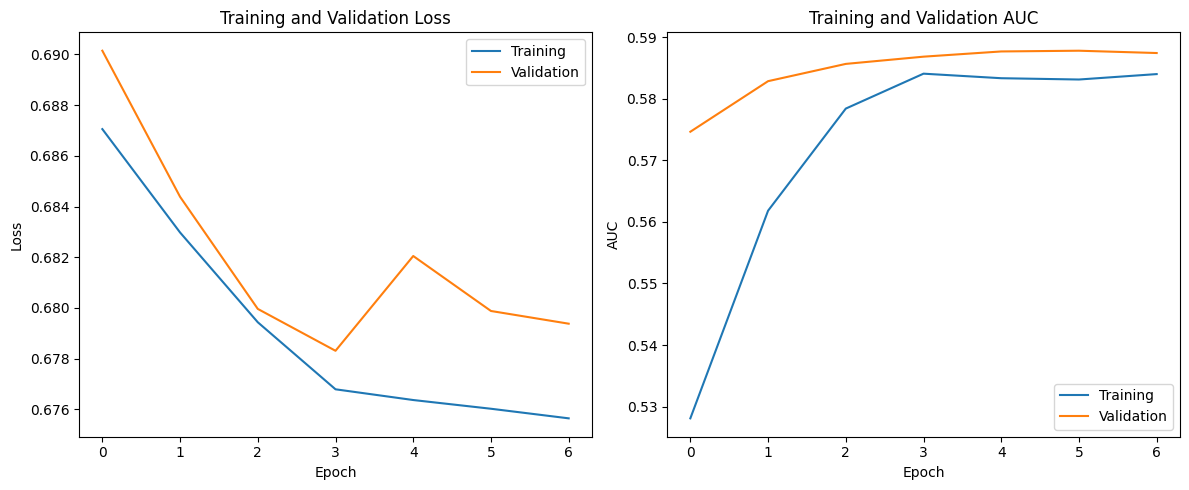

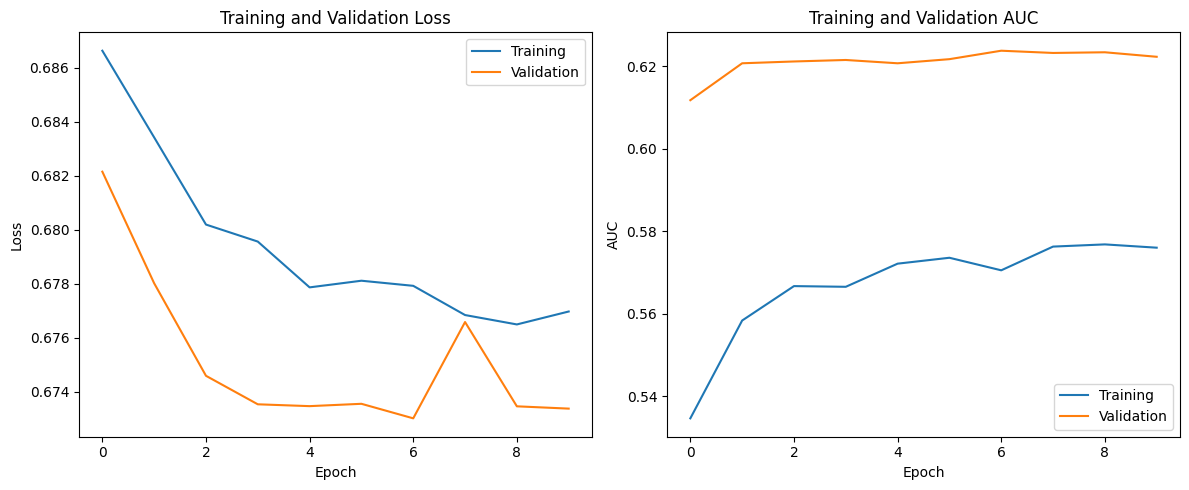

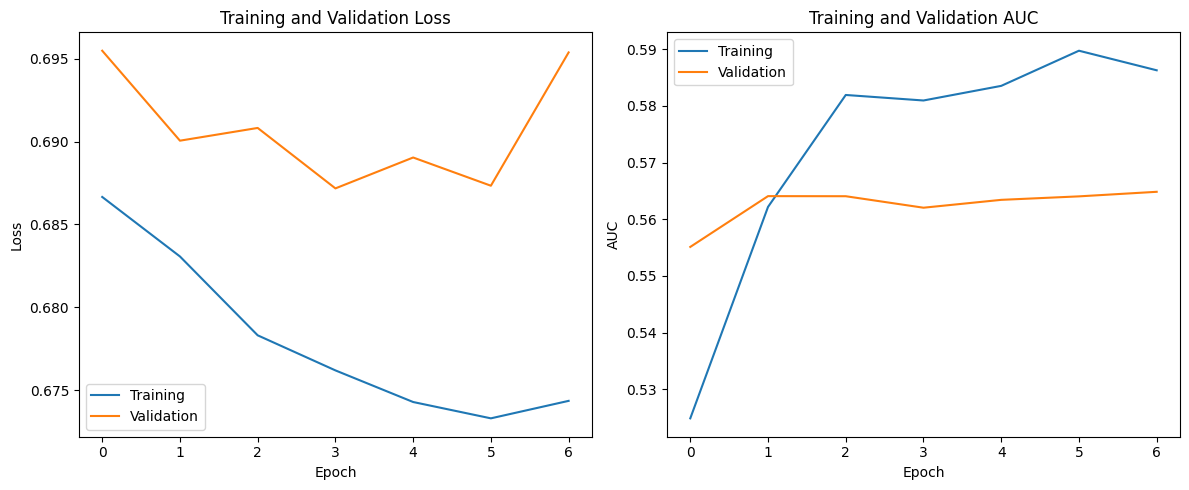

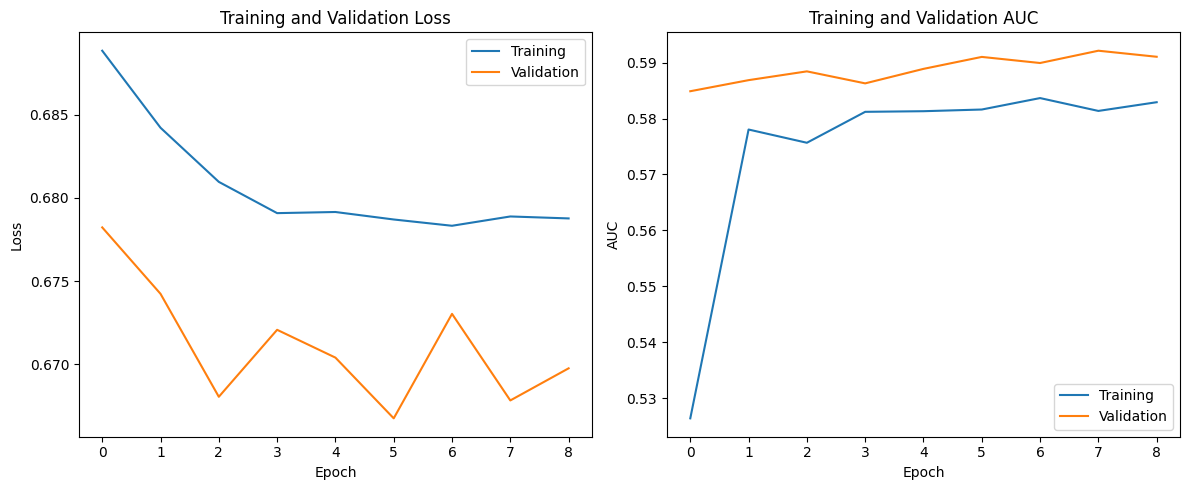

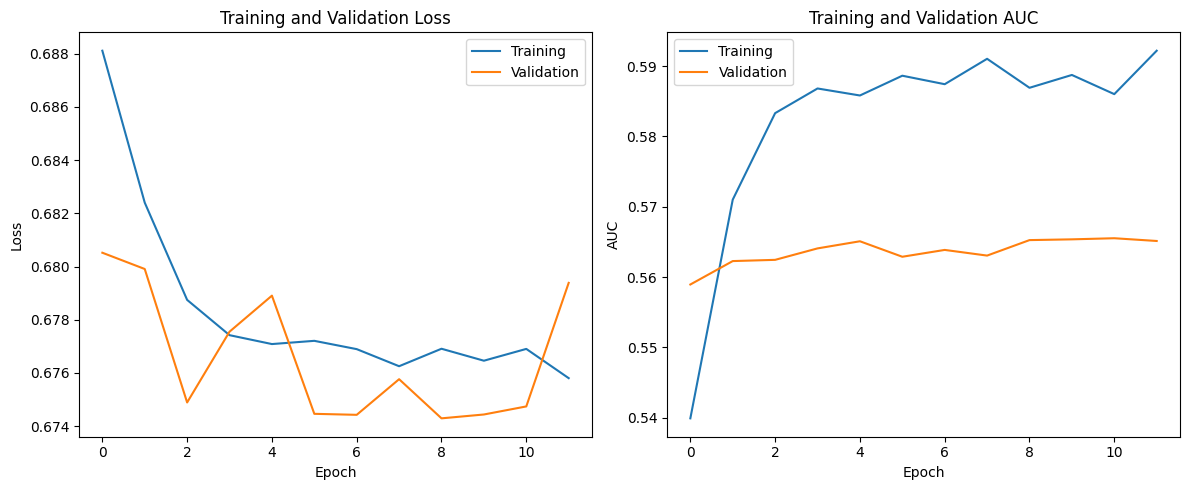

In [ ]:
for history in baseline_full_histories:
    plot_training_history(history)

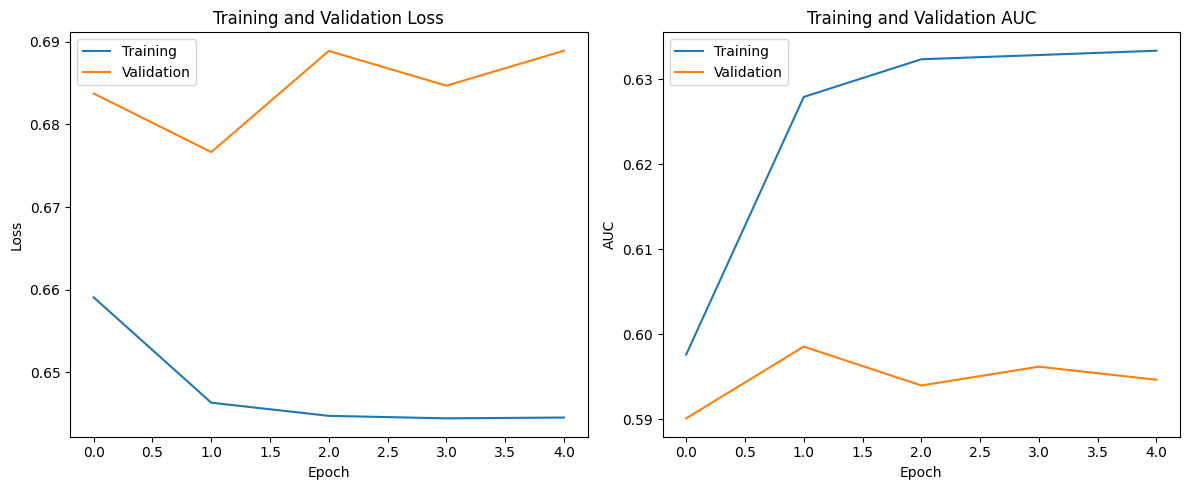

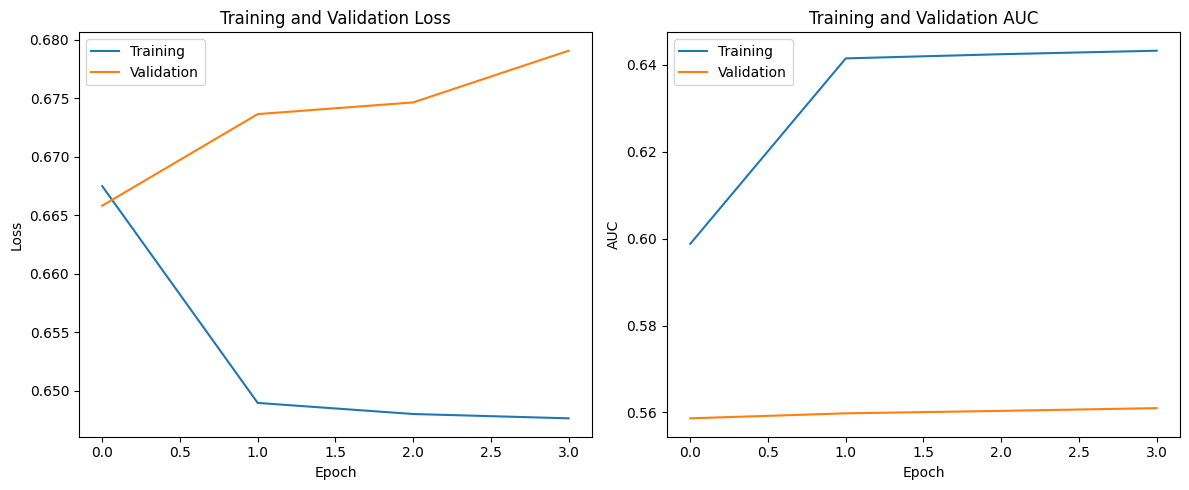

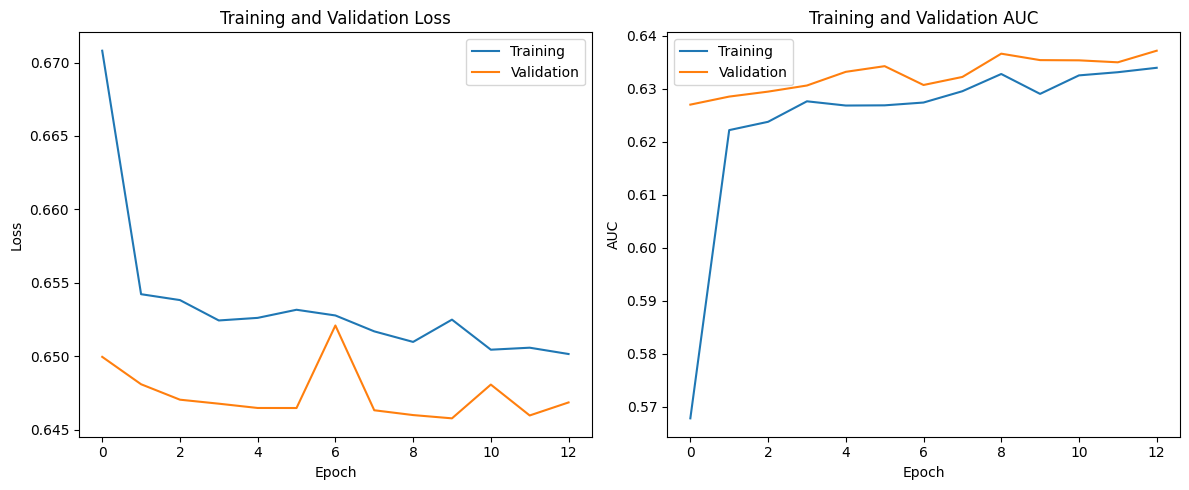

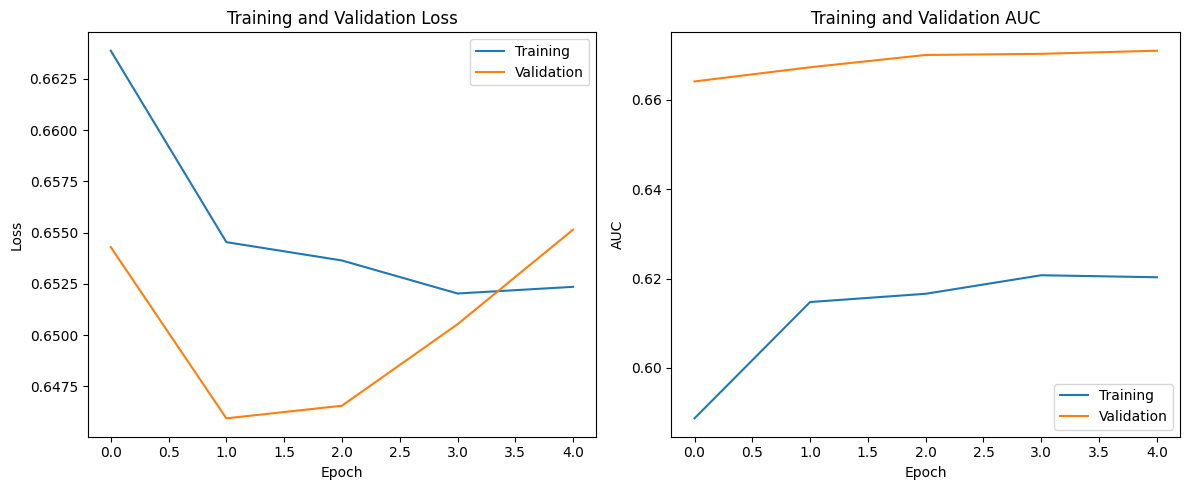

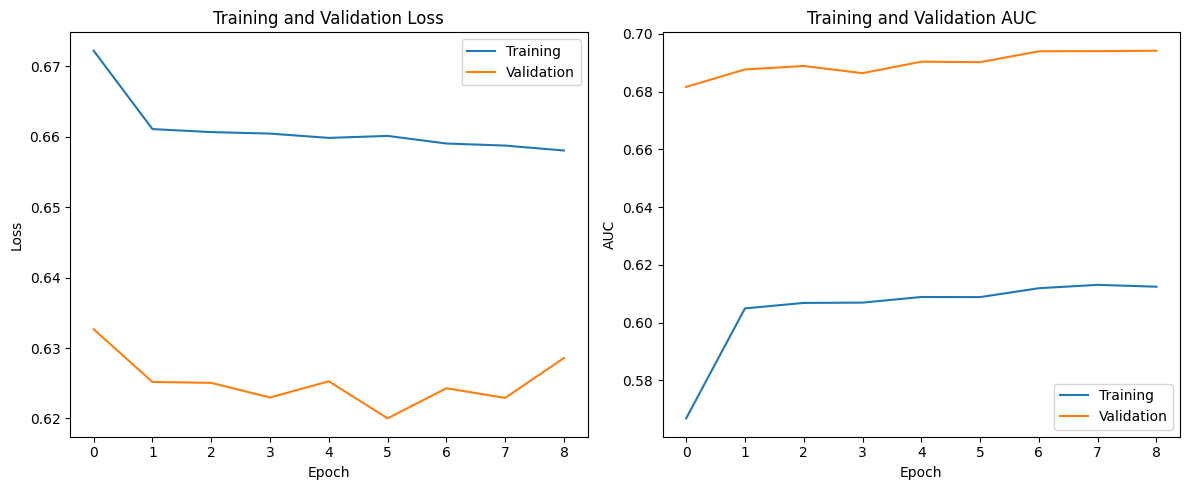

In [ ]:
for history in baseline_roi_histories:
    plot_training_history(history)

#### Baseline Validation Results

The baseline CNN for both datasets exhibits overfitting, indicated by continued improvement in training performance while validation performance plateaued or deteriorated. Early stopping based on validation loss was therefore used to retain the model weights corresponding to the best validation performance.

The baseline models were initially evaluated using five-fold
Stratified Group K-Fold cross-validation. This provided a
patient-level validation protocol while accounting for class
imbalance.

However, repeating model training across five folds substantially
increased computational cost. Due to time and hardware constraints, a patient-level 80/20 train-validation split was adopted for the remaining development.


## 80/20 Validation (RUN THIS AS WELL)

In [ ]:
def create_patient_level_split(
    image_paths,
    labels,
    groups,
    random_state=42
):

    # Create an approximately 80/20 train/validation split.



    splitter = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state
    )

    train_idx, val_idx = next(
        splitter.split(
            X=image_paths,
            y=labels,
            groups=groups
        )
    )

    # --------------------------------------------------
    # Verify patient-level separation
    # --------------------------------------------------

    train_patients = set(
        groups[train_idx]
    )

    val_patients = set(
        groups[val_idx]
    )

    overlap = train_patients.intersection(
        val_patients
    )

    print(
        f"Train patients:      {len(train_patients)}"
    )

    print(
        f"Validation patients: {len(val_patients)}"
    )

    print(
        f"Patient overlap:     {len(overlap)}"
    )

    assert len(overlap) == 0, (
        "Patient leakage detected between "
        "training and validation!"
    )

    # --------------------------------------------------
    # Verify that every image still has its own label
    # --------------------------------------------------

    print("\nImage-level class distribution")

    print(
        "Train benign:",
        np.sum(labels[train_idx] == 0)
    )

    print(
        "Train malignant:",
        np.sum(labels[train_idx] == 1)
    )

    print(
        "Validation benign:",
        np.sum(labels[val_idx] == 0)
    )

    print(
        "Validation malignant:",
        np.sum(labels[val_idx] == 1)
    )

    return train_idx, val_idx


Create fixed train/validation split and save to npy file

In [ ]:
full_train_idx_path = DATA_ROOT / "full_train_idx.npy"
full_val_idx_path = DATA_ROOT / "full_val_idx.npy"

if (
    full_train_idx_path.exists()
    and full_val_idx_path.exists()
):

    print("Loading existing Full Image train/validation split...")

    full_train_idx = np.load(full_train_idx_path)
    full_val_idx = np.load(full_val_idx_path)

else:

    print("Creating new Full Image train/validation split...")

    full_train_idx, full_val_idx = create_patient_level_split(
        image_paths=full_train_paths,
        labels=y_full,
        groups=full_groups,
        random_state=42
    )

    np.save(
        full_train_idx_path,
        full_train_idx
    )

    np.save(
        full_val_idx_path,
        full_val_idx
    )

print(f"Training samples:   {len(full_train_idx)}")
print(f"Validation samples: {len(full_val_idx)}")


Loading existing Full Image train/validation split...
Training samples:   1972
Validation samples: 486


In [ ]:
roi_train_idx_path = DATA_ROOT / "roi_train_idx.npy"
roi_val_idx_path = DATA_ROOT / "roi_val_idx.npy"

if roi_train_idx_path.exists() and roi_val_idx_path.exists():

    print("Loading existing ROI train/validation split...")

    roi_train_idx = np.load(roi_train_idx_path)
    roi_val_idx = np.load(roi_val_idx_path)

else:

    print("Creating new ROI train/validation split...")

    roi_train_idx, roi_val_idx = create_patient_level_split(
        image_paths=roi_train_paths,
        labels=y_roi,
        groups=roi_groups,
        random_state=42
    )

    np.save(
        roi_train_idx_path,
        roi_train_idx
    )

    np.save(
        roi_val_idx_path,
        roi_val_idx
    )

print(f"Training samples:   {len(roi_train_idx)}")
print(f"Validation samples: {len(roi_val_idx)}")



Loading existing ROI train/validation split...
Training samples:   2323
Validation samples: 541


In [ ]:
def run_8020_val(
    build_model,
    image_paths,
    labels,
    train_idx,
    val_idx,
    val_size=0.2,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    random_state=42,
    class_weights=None
):

    # ============================================
    # Use the supplied fixed split
    # ============================================

    train_paths = image_paths[train_idx]
    train_labels = labels[train_idx]

    val_paths = image_paths[val_idx]
    val_labels = labels[val_idx]

    # --------------------------------------------------
    # Create streaming datasets
    # --------------------------------------------------

    train_ds = create_dataset(
        train_paths,
        train_labels,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds = create_dataset(
        val_paths,
        val_labels,
        batch_size=batch_size,
        shuffle=False
    )

    print(
        f"Training images:   {len(train_paths)}"
    )

    print(
        f"Validation images: {len(val_paths)}"
    )

    # --------------------------------------------------
    # Build model
    # --------------------------------------------------

    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        restore_best_weights=True
    )

    # --------------------------------------------------
    # Train
    # --------------------------------------------------

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping],
        class_weight=class_weights,
        verbose=1
    )

    # --------------------------------------------------
    # Predictions
    # --------------------------------------------------

    y_prob = model.predict(
        val_ds,
        verbose=0
    ).ravel()

    y_true = val_labels

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # --------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    specificity = tn / (tn + fp)

    sensitivity = tp / (tp + fn)

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "false_negative_rate": 1 - sensitivity,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    # --------------------------------------------------
    # Print results
    # --------------------------------------------------

    print("\nValidation Results")

    print(
        f"Accuracy:    {results['accuracy']:.4f}"
    )

    print(
        f"Precision:   {results['precision']:.4f}"
    )

    print(
        f"Sensitivity: {results['sensitivity']:.4f}"
    )

    print(
        f"Specificity: {results['specificity']:.4f}"
    )

    print(
        f"F1:          {results['f1']:.4f}"
    )

    print(
        f"AUC:         {results['auc']:.4f}"
    )

    return (
        model,
        history,
        results,
    )


A single 80/20 patient-level split was generated using stratified group partitioning, ensuring that patients were not shared between the training and validation subsets while maintaining approximately similar class proportions

## Transfer Learning (MobileNetV2)

Used MobileNetV2 as a transfer learning model replacing the convolutional layers

In [ ]:
clear_keras()

In [ ]:
def build_model():

    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False

    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model


In [ ]:
full_model, full_history, full_results = (
    run_8020_val(
        build_model=build_model,
        image_paths=full_train_paths,
        labels=y_full,
        train_idx=full_train_idx,
        val_idx=full_val_idx,
        epochs=20,
        batch_size=32,
        learning_rate=1e-4,
        patience=3
    )
)


Patient overlap: 0

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Training patients:   999
Validation patients: 249
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 55s 574ms/step - accuracy: 0.5609 - auc: 0.5723 - loss: 0.6869 - val_accuracy: 0.5700 - val_auc: 0.6048 - val_loss: 0.6708
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.6308 - auc: 0.6872 - loss: 0.6336 - val_accuracy: 0.6070 - val_auc: 0.6130 - val_loss: 0.6627
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.6684 - auc: 0.7289 - loss: 0.6105 - val_accuracy: 0.5947 - val_auc: 0.6145 - val_loss: 0.6685
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.6810 - auc: 0.7525 - loss: 0.5910 - val_accuracy: 0.5905 - val_auc: 0.6227 - val_loss: 0.6859
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.7028 - auc: 0.7713 - loss: 0.5784 - val_accuracy: 0.5947 - val_auc: 0.6238 - val_loss: 0.6864

Validation Results
Accuracy:    0.6070
Precision:   0.

In [ ]:
roi_model, roi_history, roi_results = (
    run_8020_val(
        build_model=build_model,
        image_paths=roi_train_paths,
        labels=y_roi,
        train_idx=roi_train_idx,
        val_idx=roi_val_idx,
        epochs=20,
        batch_size=32,
        learning_rate=1e-4,
        patience=3
    )
)


Patient overlap: 0

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Training patients:   1003
Validation patients: 245
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 519s 7s/step - accuracy: 0.6229 - auc: 0.6576 - loss: 0.6589 - val_accuracy: 0.6285 - val_auc: 0.6728 - val_loss: 0.6637
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.6905 - auc: 0.7496 - loss: 0.5717 - val_accuracy: 0.6285 - val_auc: 0.6835 - val_loss: 0.6519
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.7180 - auc: 0.7780 - loss: 0.5467 - val_accuracy: 0.6377 - val_auc: 0.6902 - val_loss: 0.6337
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.7232 - auc: 0.7995 - loss: 0.5261 - val_accuracy: 0.6359 - val_auc: 0.6930 - val_loss: 0.6346
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.7464 - auc: 0.8174 - loss: 0.5090 - val_accuracy: 0.6377 - val_auc: 0.6953 - val_loss: 0.6275
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/st

| Dataset | Model | Accuracy | Precision | Sensitivity | Specificity | F1 | AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| Full Image | Baseline CNN | 0.5802 | 0.5735 | 0.2602 | 0.8364 | 0.3528 | 0.5857 |
| Full Image | MobileNetV2 | 0.6070 | 0.5223 | 0.4141 | 0.7396 | 0.4620 | 0.6135 |
| ROI | Baseline CNN | 0.6130 | 0.5634 | 0.2783 | 0.8444 | 0.3700 | 0.6294 |
| ROI | MobileNetV2 | 0.6525 | 0.6438 | 0.5618 | 0.7310 | 0.6000 | 0.7093 |


For the full images dataset, MobileNetV2 improves upon the Baseline in Accuracy, Sensitivity, F1-score and AUROC but with a precision and specificity tradeoff.

Compared with the baseline ROI model, MobileNetV2 achieves a much higher sensitivity, F1-score, and AUC on the ROI dataset. The AUC increase from 0.6294 to 0.7093 indicates a notable improvement in the model's ability to distinguish between benign and malignant cases.

#### Full History

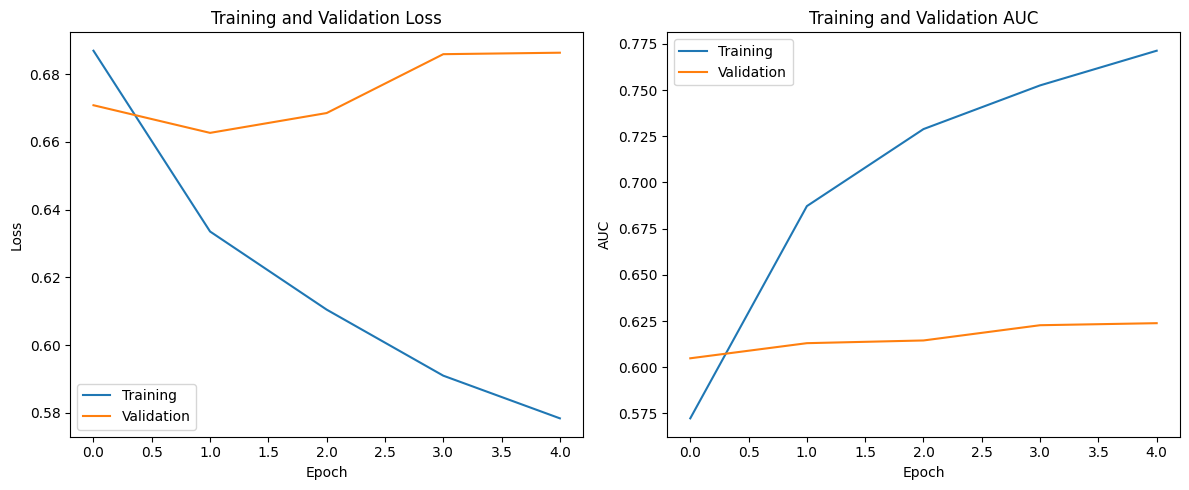

In [ ]:
plot_training_history(full_history)



#### ROI History

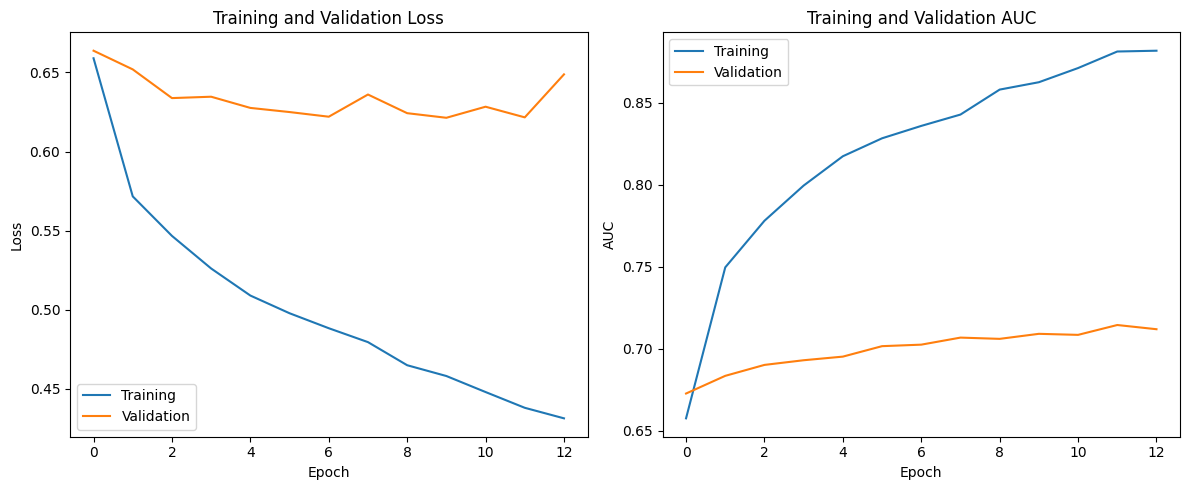

In [ ]:
plot_training_history(roi_history)


Result shows major improvement over baseline. However, validation loss still plateaus quite quickly.

## L2 + Dropout + Augmentation

Implemented L2 Regularization, Dropout and Augmentation in the model builder

In [ ]:
# Augmentation layer active only during training
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

def build_regularized_model(
    l2_val=1e-4,
    dropout_rate=0.5,
    use_augmentation=True
):
    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model_layers = [
        layers.Input(shape=(224, 224, 3))
    ]

    # Add augmentation only when requested
    if use_augmentation:
        model_layers.append(data_augmentation)

    model_layers.extend([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_val)
        ),

        layers.Dropout(dropout_rate),

        layers.Dense(
            1,
            activation="sigmoid",
            kernel_regularizer=regularizers.l2(l2_val)
        )
    ])

    return keras.Sequential(model_layers)


#### Computing Class weights in Validation Function

Implemented class weighting to the training process in the validation function

In [ ]:
def run_8020_val(
    build_model,
    image_paths,
    labels,
    train_idx,
    val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    random_state=42,
    use_class_weights=False
):

    # ============================================
    # Use the supplied fixed split
    # ============================================

    train_paths = image_paths[train_idx]
    train_labels = labels[train_idx]

    val_paths = image_paths[val_idx]
    val_labels = labels[val_idx]

    # ============================================
    # Optional class weighting
    # ============================================

    class_weights = None

    if use_class_weights:

        classes = np.unique(train_labels)

        class_weights_arr = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_labels
        )

        class_weights = dict(
            zip(classes, class_weights_arr)
        )

        print(
            f"Calculated training class weights: "
            f"{class_weights}"
        )

    else:

        print("Class weighting: DISABLED")

    # ============================================
    # Create streaming datasets
    # ============================================

    train_ds = create_dataset(
        train_paths,
        train_labels,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds = create_dataset(
        val_paths,
        val_labels,
        batch_size=batch_size,
        shuffle=False
    )

    print("\n80/20 Train-Validation Split")
    print("=" * 50)

    print(
        f"Training images:   {len(train_paths)}"
    )

    print(
        f"Validation images: {len(val_paths)}"
    )

    # ============================================
    # Build model
    # ============================================

    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    # ============================================
    # Early stopping
    # ============================================

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        restore_best_weights=True
    )

    # ============================================
    # Train
    # ============================================

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping],
        class_weight=class_weights,
        verbose=1
    )

    # ============================================
    # Predictions
    # ============================================

    y_prob = model.predict(
        val_ds,
        verbose=0
    ).ravel()

    y_true = val_labels

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # ============================================
    # Confusion matrix
    # ============================================

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # ============================================
    # Metrics
    # ============================================

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "false_negative_rate": 1 - sensitivity,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    # ============================================
    # Print results
    # ============================================

    print("\nValidation Results")

    print(
        f"Accuracy:    {results['accuracy']:.4f}"
    )

    print(
        f"Precision:   {results['precision']:.4f}"
    )

    print(
        f"Sensitivity: {results['sensitivity']:.4f}"
    )

    print(
        f"Specificity: {results['specificity']:.4f}"
    )

    print(
        f"F1:          {results['f1']:.4f}"
    )

    print(
        f"AUC:         {results['auc']:.4f}"
    )

    return (
        model,
        history,
        results,
    )


#### Model with L2 Regularization, Dropout and Augmentation

Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.5208 - auc: 0.5260 - loss: 0.7975 - val_accuracy: 0.5556 - val_auc: 0.5396 - val_loss: 0.7117
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.5771 - auc: 0.5962 - loss: 0.7176 - val_accuracy: 0.5617 - val_auc: 0.5752 - val_loss: 0.6979
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.5649 - auc: 0.5895 - loss: 0.7148 - val_accuracy: 0.5823 - val_auc: 0.5740 - val_loss: 0.6916
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.5913 - auc: 0.6425 - loss: 0.6818 - val_accuracy: 0.5823 - val_auc: 0.5904 - val_loss: 0.6893
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.6116 - auc: 0.6614 - loss: 0.6726 - val_accuracy: 0.5782 - val_auc: 0.5981 - val_loss: 0.6882
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.6293 - auc: 0.6655 - loss: 0.6712

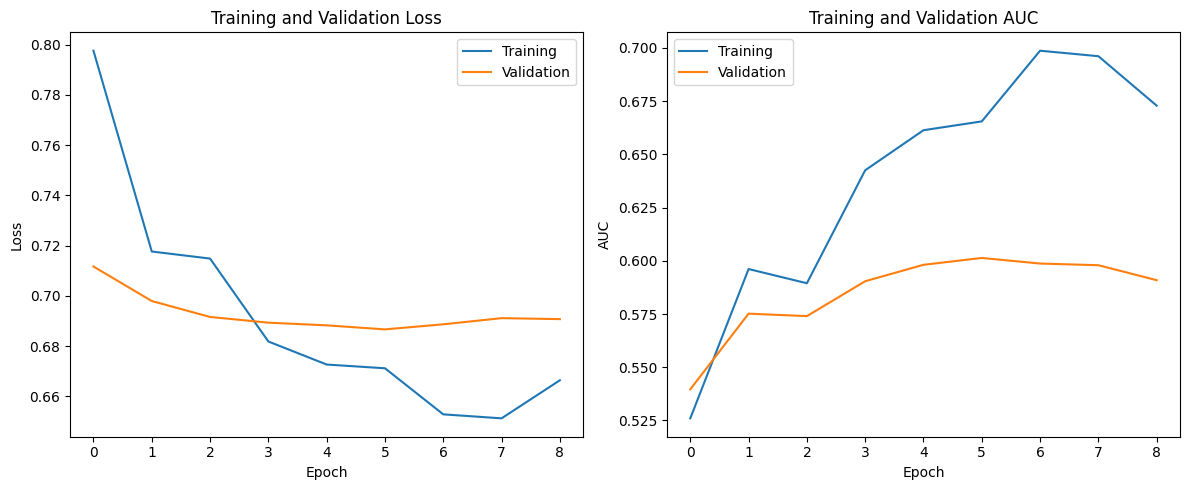

In [ ]:
full_model, full_history, full_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=True),
    image_paths=full_train_paths,
    labels=y_full,
    train_idx=full_train_idx,
    val_idx=full_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    use_class_weights=False
)

plot_training_history(full_history)

Class weighting: DISABLED
Patient overlap: 0

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Training patients: 1003
Validation patients: 245
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.5803 - auc: 0.5870 - loss: 0.7498 - val_accuracy: 0.6007 - val_auc: 0.6586 - val_loss: 0.6814
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.6358 - auc: 0.6885 - loss: 0.6508 - val_accuracy: 0.6137 - val_auc: 0.6697 - val_loss: 0.6702
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.6535 - auc: 0.7047 - loss: 0.6315 - val_accuracy: 0.6118 - val_auc: 0.6749 - val_loss: 0.6685
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.6759 - auc: 0.7356 - loss: 0.6040 - val_accuracy: 0.6248 - val_auc: 0.6827 - val_loss: 0.6573
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.6922 - auc: 0.7543 - loss: 0.5890 - val_accuracy: 0.6340 - val_auc: 0.6878 - val_loss: 0.6556
Epoch 6/20
73/73 ━━━━━━━━━━━━

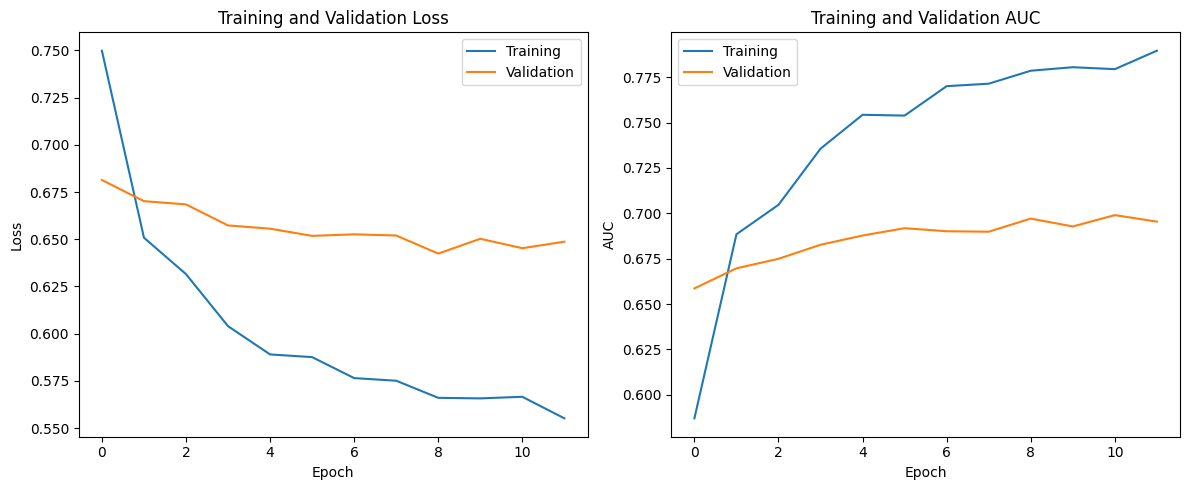

In [ ]:
roi_model, roi_history, roi_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=True),
    image_paths=roi_train_paths,
    labels=y_roi,
    train_idx=roi_train_idx,
    val_idx=roi_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    use_class_weights=False
)

plot_training_history(roi_history)

Improvements in validation loss curve is seen (less overfitting over the epochs)

#### Without Augmentation

Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 322ms/step - accuracy: 0.5243 - auc: 0.5255 - loss: 0.8226 - val_accuracy: 0.5741 - val_auc: 0.5640 - val_loss: 0.7092
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.5745 - auc: 0.5967 - loss: 0.7297 - val_accuracy: 0.6029 - val_auc: 0.5844 - val_loss: 0.6963
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.6116 - auc: 0.6478 - loss: 0.6843 - val_accuracy: 0.5823 - val_auc: 0.5930 - val_loss: 0.7013
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.6207 - auc: 0.6717 - loss: 0.6665 - val_accuracy: 0.6070 - val_auc: 0.5994 - val_loss: 0.6883
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.6308 - auc: 0.6861 - loss: 0.6599 - val_accuracy: 0.5988 - val_auc: 0.6042 - val_loss: 0.6879
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.6567 - auc: 0.7035 - loss: 0.6483

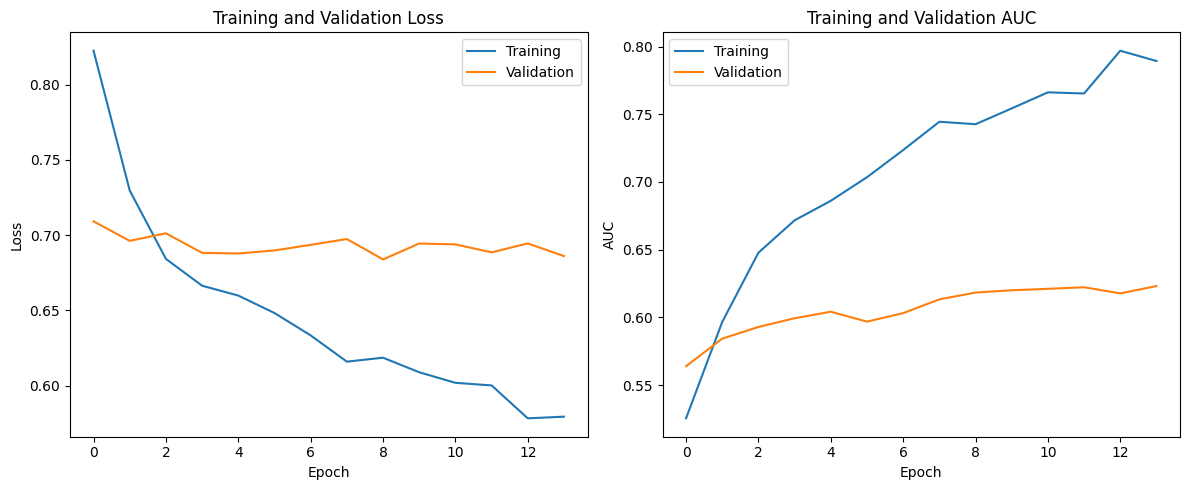

In [ ]:
full_model, full_history, full_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=False),
    image_paths=full_train_paths,
    labels=y_full,
    train_idx=full_train_idx,
    val_idx=full_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=5
)

plot_training_history(full_history)

Increased early stopping patience for Full Image model to account for variance in loss



Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 293ms/step - accuracy: 0.6139 - auc: 0.6389 - loss: 0.7002 - val_accuracy: 0.6063 - val_auc: 0.6650 - val_loss: 0.6791
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.6733 - auc: 0.7199 - loss: 0.6225 - val_accuracy: 0.6174 - val_auc: 0.6725 - val_loss: 0.6633
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.6892 - auc: 0.7535 - loss: 0.5896 - val_accuracy: 0.6174 - val_auc: 0.6752 - val_loss: 0.6625
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.7030 - auc: 0.7673 - loss: 0.5777 - val_accuracy: 0.6192 - val_auc: 0.6792 - val_loss: 0.6528
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.7017 - auc: 0.7727 - loss: 0.5722 - val_accuracy: 0.6211 - val_auc: 0.6795 - val_loss: 0.6520
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.7236 - auc: 0.7939 - loss: 0.553

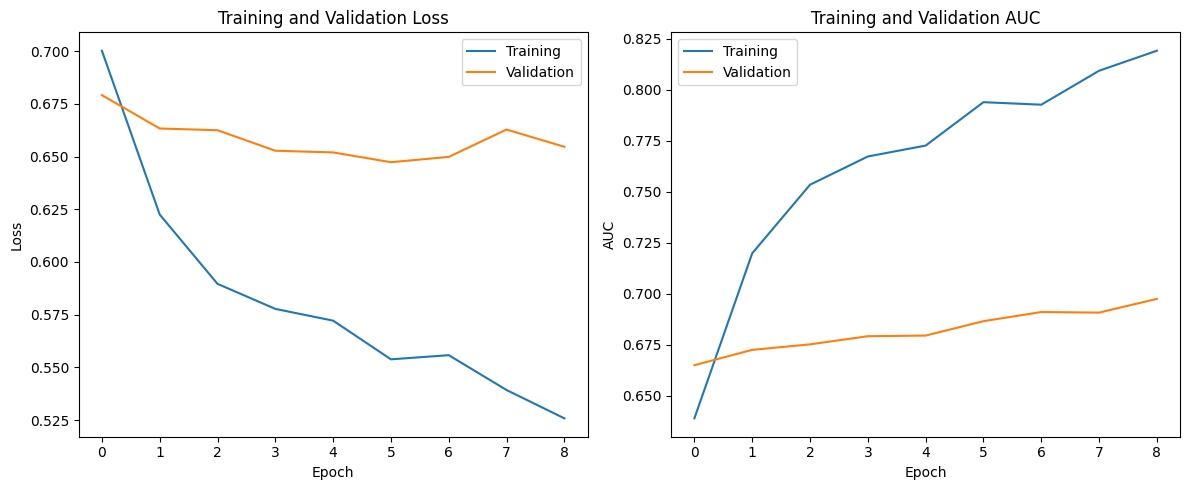

In [ ]:
roi_model, roi_history, roi_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=False),
    image_paths=roi_train_paths,
    labels=y_roi,
    train_idx=roi_train_idx,
    val_idx=roi_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3
)

plot_training_history(roi_history)

### Regularization Results

| Dataset | Training Setup | Accuracy | Precision | Sensitivity | Specificity | F1 | AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| Full Image | L2 + Dropout + Augmentation | 0.5885 | 0.4928 | 0.3434 | 0.7569 | 0.4048 | 0.6017 |
| Full Image | L2 + Dropout, Without Augmentation | 0.5905 | 0.4960 | 0.3131 | 0.7812 | 0.3839 | 0.6188 |
| ROI | L2 + Dropout + Augmentation | 0.6617 | 0.6405 | 0.6175 | 0.7000 | 0.6288 | 0.6970 |
| ROI | L2 + Dropout, Without Augmentation | 0.6322 | 0.6066 | 0.5896 | 0.6690 | 0.5980 | 0.6866 |


| Dataset | Metric | With Augmentation | Without Augmentation | Change |
|---|---|---:|---:|---:|
| Full Image | Accuracy | 0.5885 | 0.5905 | -0.0020 |
| Full Image | Precision | 0.4928 | 0.4960 | -0.0032 |
| Full Image | Sensitivity | 0.3434 | 0.3131 | +0.0303 |
| Full Image | Specificity | 0.7569 | 0.7812 | -0.0243 |
| Full Image | F1 | 0.4048 | 0.3839 | +0.0209 |
| Full Image | AUC | 0.6017 | 0.6188 | -0.0171 |
| ROI | Accuracy | 0.6617 | 0.6322 | +0.0295 |
| ROI | Precision | 0.6405 | 0.6066 | +0.0339 |
| ROI | Sensitivity | 0.6175 | 0.5896 | +0.0279 |
| ROI | Specificity | 0.7000 | 0.6690 | +0.0310 |
| ROI | F1 | 0.6288 | 0.5980 | +0.0308 |
| ROI | AUC | 0.6970 | 0.6866 | +0.0104 |


Augmentation improved the ROI metrics by ~3% while the Full Image model gives slight tradeoffs

| Dataset | Model | Accuracy | Precision | Sensitivity | Specificity | F1 | AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| Full Image | MobileNetV2 | 0.6070 | 0.5223 | 0.4141 | 0.7396 | 0.4620 | 0.6135 |
| Full Image | L2 + Dropout + Augmentation | 0.5885 | 0.4928 | 0.3434 | 0.7569 | 0.4048 | 0.6017 |
| ROI | MobileNetV2 | 0.6525 | 0.6438 | 0.5618 | 0.7310 | 0.6000 | 0.7093 |
| ROI | L2 + Dropout + Augmentation | 0.6617 | 0.6405 | 0.6175 | 0.7000 | 0.6288 | 0.6970 |


Full Image model without regularization still performed better than the regularized model.

For the ROI Model, regularization improved the sensitivity by ~4% while having a ~3 trade-off for specificity, as sensitivity has a higher priority, regularization gives a worthwhile improvement.

### Weighted Class

Calculated training class weights: {np.int32(0): np.float64(0.931067044381492), np.int32(1): np.float64(1.0799561883899234)}

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.5046 - auc: 0.5214 - loss: 0.7772 - val_accuracy: 0.5514 - val_auc: 0.5542 - val_loss: 0.7175
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.5497 - auc: 0.5716 - loss: 0.7260 - val_accuracy: 0.5700 - val_auc: 0.5838 - val_loss: 0.7021
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.5969 - auc: 0.6306 - loss: 0.6933 - val_accuracy: 0.5494 - val_auc: 0.5843 - val_loss: 0.7096
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.5862 - auc: 0.6264 - loss: 0.6926 - val_accuracy: 0.5885 - val_auc: 0.5831 - val_loss: 0.6966
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6105 - auc: 0.6536 - loss: 0.6798 - val_accuracy: 0.5823 - val_auc: 0.5673 - val_loss: 0.6950

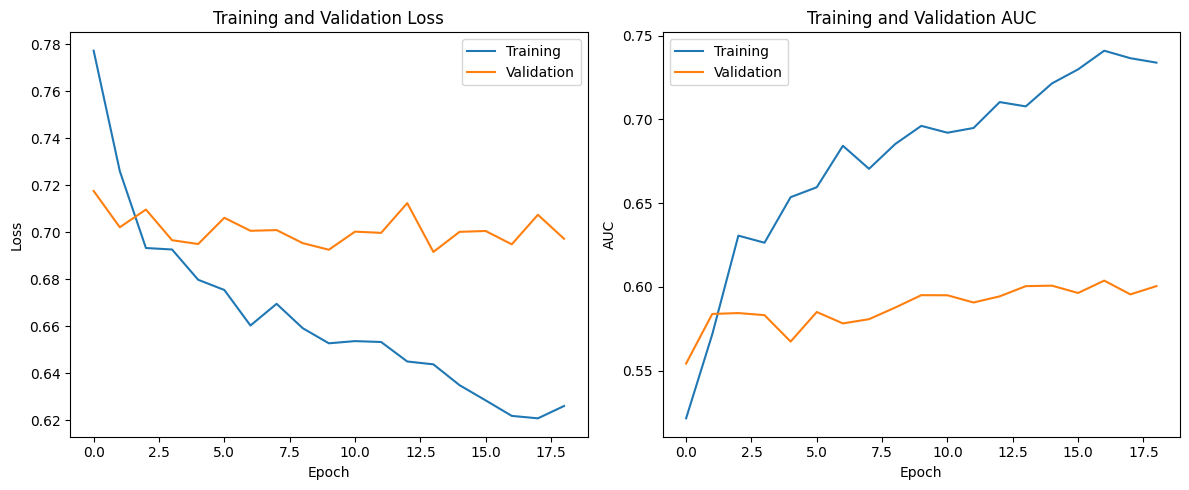

In [ ]:
full_model, full_history, full_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=True),
    image_paths=full_train_paths,
    labels=y_full,
    train_idx=full_train_idx,
    val_idx=full_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=5,
    use_class_weights=True
)

plot_training_history(full_history)

Calculated training class weights: {np.int32(0): np.float64(0.8338119167264896), np.int32(1): np.float64(1.2489247311827958)}

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.5454 - auc: 0.5656 - loss: 0.7854 - val_accuracy: 0.5952 - val_auc: 0.6489 - val_loss: 0.6746
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.6220 - auc: 0.6842 - loss: 0.6709 - val_accuracy: 0.6137 - val_auc: 0.6667 - val_loss: 0.6647
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.6616 - auc: 0.7210 - loss: 0.6355 - val_accuracy: 0.6248 - val_auc: 0.6786 - val_loss: 0.6552
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.6362 - auc: 0.7204 - loss: 0.6315 - val_accuracy: 0.6137 - val_auc: 0.6802 - val_loss: 0.6516
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.6690 - auc: 0.7409 - loss: 0.6123 - val_accuracy: 0.6044 - val_auc: 0.6812 - val_loss: 0.650

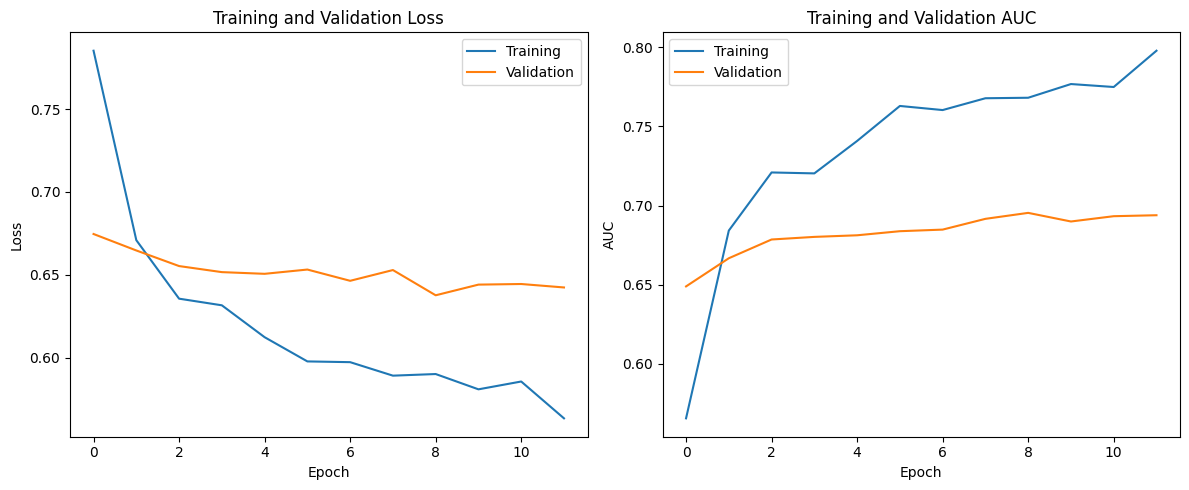

In [ ]:
roi_model, roi_history, roi_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=True),
    image_paths=roi_train_paths,
    labels=y_roi,
    train_idx=roi_train_idx,
    val_idx=roi_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    use_class_weights=True
)

plot_training_history(roi_history)

Weighted-class training substantially improves sensitivity and F1 with a trade-off in specificity with the Full Image model.

For the ROI model, weighted-class training reduced performance by ~3% on all metrics

## Fine-tuning

Unfreezing last 20 mobilenetv2 layers and using a low learning rate (1e-5)

In [ ]:
def build_finetune_model(
    l2_val=1e-4,
    dropout_rate=0.5,
    use_augmentation=True,
    fine_tune_layers=20
):
    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # -----------------------------------------
    # Freeze the base model initially
    # -----------------------------------------

    base_model.trainable = True

    # Freeze all but the last N layers
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Keep BatchNormalization layers frozen
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    # -----------------------------------------
    # Build model
    # -----------------------------------------

    model_layers = [
        layers.Input(shape=(224, 224, 3))
    ]

    if use_augmentation:
        model_layers.append(data_augmentation)

    model_layers.extend([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_val)
        ),

        layers.Dropout(dropout_rate),

        layers.Dense(
            1,
            activation="sigmoid",
            kernel_regularizer=regularizers.l2(l2_val)
        )
    ])

    model = keras.Sequential(model_layers)

    return model


In [ ]:
test_model = build_finetune_model(
    l2_val=1e-4,
    dropout_rate=0.5,
    use_augmentation=True,
    fine_tune_layers=20
)

print("Total parameters:",
      test_model.count_params())

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in test_model.trainable_weights
    )
)

In [ ]:
clear_keras()

Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 210ms/step - accuracy: 0.5061 - auc: 0.5064 - loss: 0.7789 - val_accuracy: 0.5473 - val_auc: 0.5698 - val_loss: 0.7010
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5710 - auc: 0.5935 - loss: 0.7045 - val_accuracy: 0.5802 - val_auc: 0.5850 - val_loss: 0.6876
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.5984 - auc: 0.6263 - loss: 0.6904 - val_accuracy: 0.5761 - val_auc: 0.5811 - val_loss: 0.6882
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.6136 - auc: 0.6478 - loss: 0.6803 - val_accuracy: 0.5658 - val_auc: 0.5886 - val_loss: 0.7038
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.6141 - auc: 0.6533 - loss: 0.6794 - val_accuracy: 0.5658 - val_auc: 0.6042 - val_loss: 0.6867
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.6126 - auc: 0.6673 - loss: 0.668

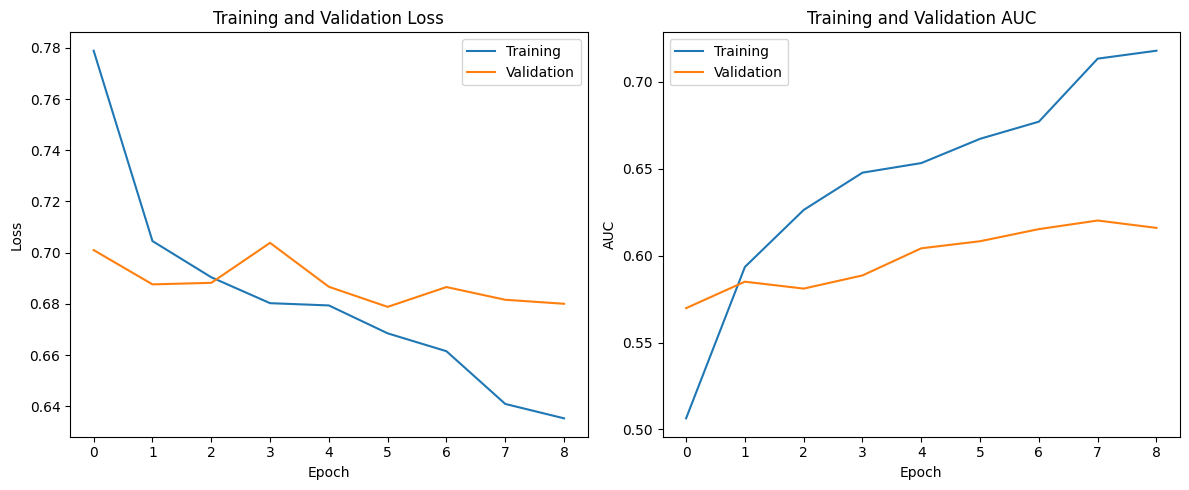

In [ ]:
full_model, full_history, full_results = (
    run_8020_val(
        build_model=lambda: build_finetune_model(
            l2_val=1e-4,
            dropout_rate=0.5,
            use_augmentation=True,
            fine_tune_layers=20
        ),
        image_paths=full_train_paths,
        labels=y_full,
        train_idx=full_train_idx,
        val_idx=full_val_idx,
        epochs=20,
        batch_size=32,
        learning_rate=1e-5,
        patience=3,
        use_class_weights=False
    )
)

plot_training_history(full_history)


Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.6212 - auc: 0.6472 - loss: 0.6764 - val_accuracy: 0.6192 - val_auc: 0.6695 - val_loss: 0.6642
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.6522 - auc: 0.7047 - loss: 0.6262 - val_accuracy: 0.6248 - val_auc: 0.6803 - val_loss: 0.6542
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.6780 - auc: 0.7330 - loss: 0.6066 - val_accuracy: 0.6303 - val_auc: 0.6914 - val_loss: 0.6462
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.6883 - auc: 0.7440 - loss: 0.5977 - val_accuracy: 0.6266 - val_auc: 0.6939 - val_loss: 0.6416
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.7056 - auc: 0.7574 - loss: 0.5859 - val_accuracy: 0.6322 - val_auc: 0.6976 - val_loss: 0.6554
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.7086 - auc: 0.7717 - loss: 0.5

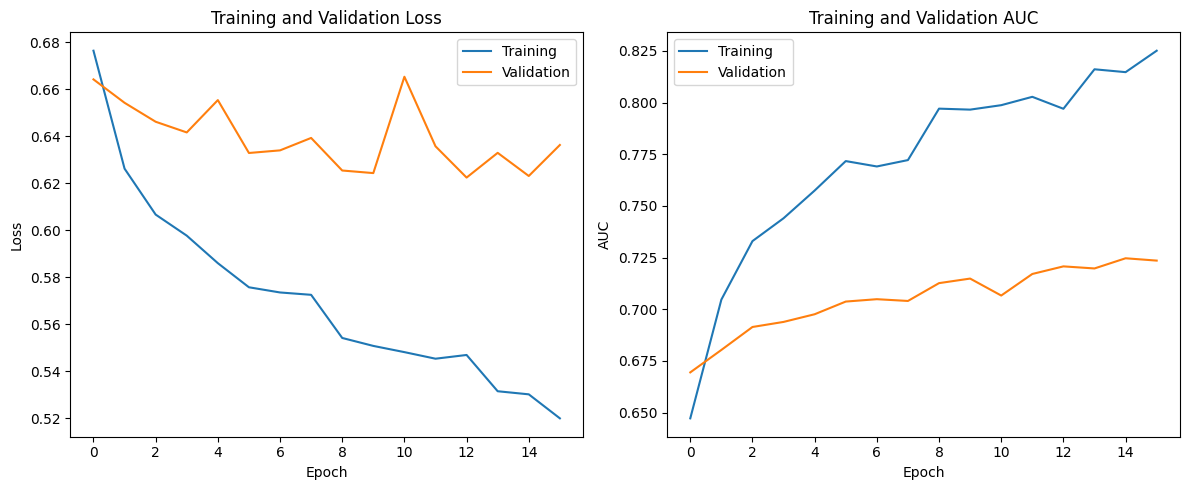

In [ ]:
roi_model, roi_history, roi_results = (
    run_8020_val(
        build_model=lambda: build_finetune_model(
            l2_val=1e-4,
            dropout_rate=0.5,
            use_augmentation=True,
            fine_tune_layers=20
        ),
        image_paths=roi_train_paths,
        labels=y_roi,
        train_idx=roi_train_idx,
        val_idx=roi_val_idx,
        epochs=20,
        batch_size=32,
        learning_rate=1e-5,
        patience=3,
        use_class_weights=False
    )
)

plot_training_history(roi_history)


### Fine Tuning Results

| Dataset | Model | Accuracy | Precision | Sensitivity | Specificity | F1 | AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| Full Image | MobileNetV2 | 0.6070 | 0.5223 | 0.4141 | 0.7396 | 0.4620 | 0.6135 |
| Full Image | L2 + Dropout + Augmentation | 0.5885 | 0.4928 | 0.3434 | 0.7569 | 0.4048 | 0.6017 |
| Full Image | Weighted Class | 0.5864 | 0.4917 | 0.4495 | 0.6806 | 0.4697 | 0.6003 |
| Full Image | Fine-Tuned | 0.5679 | 0.4434 | 0.2374 | 0.7951 | 0.3092 | 0.6085 |
| ROI | MobileNetV2 | 0.6525 | 0.6438 | 0.5618 | 0.7310 | 0.6000 | 0.7093 |
| ROI | L2 + Dropout + Augmentation | **0.6617** | 0.6405 | **0.6175** | 0.7000 | **0.6288** | 0.6970 |
| ROI | Weighted Class | 0.6322 | 0.6066 | 0.5896 | 0.6690 | 0.5980 | 0.6955 |
| ROI | Fine-Tuned | 0.6525 | **0.6567** | 0.5259 | **0.7621** | 0.5841 | **0.7204** |


Fine-tuning produced mixed results. It improved some metrics on the ROI dataset, particularly AUC and specificity, but did not provide an overall improvement across all evaluation metrics.

## Chosen Models for Multi-Input Model

In [ ]:
clear_keras()

Full Image: The MobileNetV2 model has the highest accuracy (0.6070), sensitivity (0.4141), and F1-score (0.4620). The regularized model has slightly higher specificity (0.7569), while the fine-tuned model has the highest specificity (0.7951) but the lowest sensitivity and F1-score.

In [ ]:
full_model, full_history, full_results = (
    run_8020_val(
        build_model=build_model,
        image_paths=full_train_paths,
        labels=y_full,
        train_idx=full_train_idx,
        val_idx=full_val_idx,
        epochs=20,
        batch_size=32,
        learning_rate=1e-4,
        patience=3
    )
)

Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   1972
Validation images: 486
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 323ms/step - accuracy: 0.5629 - auc: 0.5804 - loss: 0.6895 - val_accuracy: 0.5432 - val_auc: 0.5563 - val_loss: 0.7074
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.6318 - auc: 0.6781 - loss: 0.6411 - val_accuracy: 0.5391 - val_auc: 0.5794 - val_loss: 0.7074
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6618 - auc: 0.7278 - loss: 0.6126 - val_accuracy: 0.5864 - val_auc: 0.5973 - val_loss: 0.6775
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.6729 - auc: 0.7477 - loss: 0.5954 - val_accuracy: 0.5967 - val_auc: 0.6005 - val_loss: 0.6802
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6831 - auc: 0.7561 - loss: 0.5863 - val_accuracy: 0.5926 - val_auc: 0.6117 - val_loss: 0.6914
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.7079 - auc: 0.7851 - loss: 0.5654

ROI: The regularized model has the highest accuracy (0.6617), sensitivity (0.6175), and F1-score (0.6288). The fine-tuned model has the highest precision (0.6567), specificity (0.7621), and AUC (0.7204).

In [ ]:
roi_model, roi_history, roi_results = run_8020_val(
    build_model=lambda: build_regularized_model(l2_val=1e-4, dropout_rate=0.5, use_augmentation=True),
    image_paths=roi_train_paths,
    labels=y_roi,
    train_idx=roi_train_idx,
    val_idx=roi_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    patience=3,
    use_class_weights=False
)

Class weighting: DISABLED

80/20 Train-Validation Split
Training images:   2323
Validation images: 541
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.6164 - auc: 0.6386 - loss: 0.7008 - val_accuracy: 0.6155 - val_auc: 0.6697 - val_loss: 0.6681
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.6548 - auc: 0.7019 - loss: 0.6397 - val_accuracy: 0.6174 - val_auc: 0.6787 - val_loss: 0.6626
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.6715 - auc: 0.7183 - loss: 0.6176 - val_accuracy: 0.6359 - val_auc: 0.6817 - val_loss: 0.6606
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.6728 - auc: 0.7299 - loss: 0.6098 - val_accuracy: 0.6266 - val_auc: 0.6817 - val_loss: 0.6531
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.6896 - auc: 0.7518 - loss: 0.5915 - val_accuracy: 0.6377 - val_auc: 0.6877 - val_loss: 0.6528
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.6814 - auc: 0.7381 - loss: 0.59

## Multi-Input Model

In [ ]:
clear_keras()

In [ ]:
print("FULL TRAIN:", len(full_train_paths))
print("ROI TRAIN :", len(roi_train_paths))

print("FULL TEST :", len(full_test_paths))
print("ROI TEST  :", len(roi_test_paths))


FULL TRAIN: 2458
ROI TRAIN : 2864
FULL TEST : 399
ROI TEST  : 547


Lookup Table for full images

In [ ]:
def get_full_key(path):
    """
    FULL filename:
        Calc_P_00008_LEFT_CC.png

    Key:
        Calc_P_00008_LEFT_CC
    """
    filename = os.path.basename(path)
    return os.path.splitext(filename)[0]


full_lookup = {
    get_full_key(path): path
    for path in full_train_paths
}

print("Number of FULL image keys:", len(full_lookup))

print("\nExamples:")
for key, path in list(full_lookup.items())[:10]:
    print(key, "→", path)


Number of FULL image keys: 2458

Examples:
Calc_P_00007_LEFT_CC → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00007_LEFT_CC.png
Calc_P_00007_LEFT_MLO → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00007_LEFT_MLO.png
Calc_P_00008_LEFT_CC → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00008_LEFT_CC.png
Calc_P_00008_LEFT_MLO → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00008_LEFT_MLO.png
Calc_P_00008_RIGHT_CC → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00008_RIGHT_CC.png
Calc_P_00008_RIGHT_MLO → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign/Calc_P_00008_RIGHT_MLO.png
Calc_P_00010_LEFT_CC → /content/drive/MyDrive/Databases/cbis_ddsm_processed/cbis_ddsm_processed_full/train/benign

Convert ROI path to Full Image key

In [ ]:
import re

def get_roi_base_key(path):
    """
    ROI filename:
        Calc_P_00008_LEFT_CC_3.png

    Base key:
        Calc_P_00008_LEFT_CC
    """

    filename = os.path.basename(path)
    filename = os.path.splitext(filename)[0]

    # Remove ONLY the final _number
    base_key = re.sub(r'_\d+$', '', filename)

    return base_key


print("--- ROI BASE KEYS ---")

for path in roi_train_paths[:20]:
    print(
        os.path.basename(path),
        "→",
        get_roi_base_key(path)
    )


--- ROI BASE KEYS ---
Calc_P_00007_LEFT_CC_1.png → Calc_P_00007_LEFT_CC
Calc_P_00007_LEFT_MLO_1.png → Calc_P_00007_LEFT_MLO
Calc_P_00008_LEFT_CC_1.png → Calc_P_00008_LEFT_CC
Calc_P_00008_LEFT_CC_2.png → Calc_P_00008_LEFT_CC
Calc_P_00008_LEFT_CC_3.png → Calc_P_00008_LEFT_CC
Calc_P_00008_LEFT_MLO_1.png → Calc_P_00008_LEFT_MLO
Calc_P_00008_LEFT_MLO_2.png → Calc_P_00008_LEFT_MLO
Calc_P_00008_LEFT_MLO_3.png → Calc_P_00008_LEFT_MLO
Calc_P_00008_RIGHT_CC_1.png → Calc_P_00008_RIGHT_CC
Calc_P_00008_RIGHT_CC_2.png → Calc_P_00008_RIGHT_CC
Calc_P_00008_RIGHT_CC_3.png → Calc_P_00008_RIGHT_CC
Calc_P_00008_RIGHT_CC_4.png → Calc_P_00008_RIGHT_CC
Calc_P_00008_RIGHT_CC_5.png → Calc_P_00008_RIGHT_CC
Calc_P_00008_RIGHT_MLO_1.png → Calc_P_00008_RIGHT_MLO
Calc_P_00008_RIGHT_MLO_2.png → Calc_P_00008_RIGHT_MLO
Calc_P_00008_RIGHT_MLO_3.png → Calc_P_00008_RIGHT_MLO
Calc_P_00008_RIGHT_MLO_4.png → Calc_P_00008_RIGHT_MLO
Calc_P_00008_RIGHT_MLO_5.png → Calc_P_00008_RIGHT_MLO
Calc_P_00010_LEFT_CC_1.png → Calc_P_0001

Check ROI to Full Mammogram matching

In [ ]:
matched = 0
unmatched = []

for roi_path in roi_train_paths:

    roi_key = get_roi_base_key(roi_path)

    if roi_key in full_lookup:
        matched += 1
    else:
        unmatched.append(roi_path)


print("Total ROI images :", len(roi_train_paths))
print("Matched ROIs     :", matched)
print("Unmatched ROIs   :", len(unmatched))


if unmatched:
    print("\nFirst unmatched ROIs:")
    for path in unmatched[:20]:
        print(os.path.basename(path))


Total ROI images : 2864
Matched ROIs     : 2864
Unmatched ROIs   : 0


Create Fusion Samples

In [ ]:
fusion_full_paths = []
fusion_roi_paths = []
fusion_labels = []
fusion_full_indices = []

# ------------------------------------------------------------
# FULL image key -> index
# ------------------------------------------------------------

full_index_lookup = {
    get_full_key(path): index
    for index, path in enumerate(full_train_paths)
}


# ------------------------------------------------------------
# Create fusion pairs
# ------------------------------------------------------------

for roi_path, roi_label in zip(
    roi_train_paths,
    y_roi
):

    # Example:
    #
    # ROI:
    # Calc_P_00008_LEFT_CC_3.png
    #
    # FULL:
    # Calc_P_00008_LEFT_CC.png

    roi_key = get_roi_base_key(roi_path)


    # --------------------------------------------------------
    # Find corresponding FULL image
    # --------------------------------------------------------

    if roi_key not in full_lookup:

        raise ValueError(
            f"No matching FULL image found for ROI: "
            f"{os.path.basename(roi_path)}"
        )

    full_path = full_lookup[roi_key]

    full_index = full_index_lookup[roi_key]


    # --------------------------------------------------------
    # Store fusion pair
    # --------------------------------------------------------

    fusion_full_paths.append(full_path)

    fusion_roi_paths.append(roi_path)

    # IMPORTANT:
    # The target belongs to THIS ROI.
    fusion_labels.append(roi_label)

    # Store corresponding FULL image index
    fusion_full_indices.append(full_index)


# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

fusion_full_paths = np.array(
    fusion_full_paths
)

fusion_roi_paths = np.array(
    fusion_roi_paths
)

fusion_labels = np.array(
    fusion_labels,
    dtype=np.int32
)

fusion_full_indices = np.array(
    fusion_full_indices,
    dtype=np.int64
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Fusion samples:", len(fusion_full_paths))
print("FULL :", len(fusion_full_paths))
print("ROI  :", len(fusion_roi_paths))
print("LABEL:", len(fusion_labels))

print("\nFusion label distribution:")

print(
    "Benign:",
    np.sum(fusion_labels == 0)
)

print(
    "Malignant:",
    np.sum(fusion_labels == 1)
)


Fusion samples: 2864
FULL : 2864
ROI  : 2864
LABEL: 2864

Fusion label distribution:
Benign: 1683
Malignant: 1181


In [ ]:
print("FULL TRAIN:", len(full_train_idx))
print("FULL VAL  :", len(full_val_idx))

train_groups = set(full_groups[full_train_idx])
val_groups = set(full_groups[full_val_idx])

print("Train patients:", len(train_groups))
print("Val patients  :", len(val_groups))
print("Patient overlap:", len(train_groups & val_groups))


FULL TRAIN: 1972
FULL VAL  : 486
Train patients: 999
Val patients  : 249
Patient overlap: 0


Map Existing Full Split to Fusion Split

In [ ]:
full_train_set = set(full_train_idx)
full_val_set = set(full_val_idx)

fusion_train_idx = np.array([
    i
    for i, full_idx in enumerate(fusion_full_indices)
    if full_idx in full_train_set
], dtype=np.int64)

fusion_val_idx = np.array([
    i
    for i, full_idx in enumerate(fusion_full_indices)
    if full_idx in full_val_set
], dtype=np.int64)


print("Fusion training samples  :", len(fusion_train_idx))
print("Fusion validation samples:", len(fusion_val_idx))

print(
    "Total:",
    len(fusion_train_idx) + len(fusion_val_idx)
)


Fusion training samples  : 2276
Fusion validation samples: 588
Total: 2864
Split check: PASSED


Create Fusion Train / Validation Arrays

In [ ]:
fusion_train_full_paths = fusion_full_paths[fusion_train_idx]
fusion_train_roi_paths = fusion_roi_paths[fusion_train_idx]
fusion_train_labels = fusion_labels[fusion_train_idx]

fusion_val_full_paths = fusion_full_paths[fusion_val_idx]
fusion_val_roi_paths = fusion_roi_paths[fusion_val_idx]
fusion_val_labels = fusion_labels[fusion_val_idx]


print("Fusion training samples  :", len(fusion_train_labels))
print("Fusion validation samples:", len(fusion_val_labels))

print("\nTraining:")
print("FULL :", len(fusion_train_full_paths))
print("ROI  :", len(fusion_train_roi_paths))
print("LABEL:", len(fusion_train_labels))

print("\nValidation:")
print("FULL :", len(fusion_val_full_paths))
print("ROI  :", len(fusion_val_roi_paths))
print("LABEL:", len(fusion_val_labels))


Fusion training samples  : 2276
Fusion validation samples: 588

Training:
FULL : 2276
ROI  : 2276
LABEL: 2276

Validation:
FULL : 588
ROI  : 588
LABEL: 588


### Model Builder

In [ ]:
print("Lengths:")
print(len(fusion_full_paths))
print(len(fusion_roi_paths))
print(len(fusion_labels))


Lengths:
2864
2864
2864


Build Fusion Model using same parameters from chosen models as close as possible

In [ ]:

def build_fusion_model(
    l2_val=1e-4,
    dropout_rate=0.5,
    use_augmentation=True,
    fine_tune_layers=0
):

    # =========================================================
    # FULL IMAGE BRANCH
    # =========================================================

    full_base = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        name="full_mobilenetv2"
    )

    full_base.trainable = True

    # Freeze all but last N layers
    for layer in full_base.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Keep BatchNorm frozen during fine-tuning
    for layer in full_base.layers:
        if isinstance(
            layer,
            keras.layers.BatchNormalization
        ):
            layer.trainable = False


    # =========================================================
    # ROI BRANCH
    # =========================================================

    roi_base = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        name="roi_mobilenetv2"
    )

    roi_base.trainable = True

    # Freeze all but last N layers
    for layer in roi_base.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Keep BatchNorm frozen
    for layer in roi_base.layers:
        if isinstance(
            layer,
            keras.layers.BatchNormalization
        ):
            layer.trainable = False


    # =========================================================
    # INPUTS
    # =========================================================

    full_input = layers.Input(
        shape=(224, 224, 3),
        name="full_input"
    )

    roi_input = layers.Input(
        shape=(224, 224, 3),
        name="roi_input"
    )


    # =========================================================
    # DATA AUGMENTATION
    # =========================================================

    if use_augmentation:

        augmentation = keras.Sequential(
            [
                layers.RandomRotation(0.05),
                layers.RandomZoom(0.05),
            ],
            name="augmentation"
        )

        full_augmented = augmentation(full_input)
        roi_augmented = augmentation(roi_input)

    else:

        full_augmented = full_input
        roi_augmented = roi_input


    # =========================================================
    # FEATURE EXTRACTION
    # =========================================================

    full_features = full_base(
        full_augmented,
        training=False
    )

    roi_features = roi_base(
        roi_augmented,
        training=False
    )


    # =========================================================
    # GLOBAL AVERAGE POOLING
    # =========================================================

    full_features = layers.GlobalAveragePooling2D(
        name="full_global_average_pooling"
    )(full_features)

    roi_features = layers.GlobalAveragePooling2D(
        name="roi_global_average_pooling"
    )(roi_features)


    # =========================================================
    # CONCATENATE FULL + ROI FEATURES
    # =========================================================

    fused_features = layers.Concatenate(
        name="feature_fusion"
    )(
        [
            full_features,
            roi_features
        ]
    )


    # =========================================================
    # CLASSIFICATION HEAD
    # =========================================================

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
        name="fusion_dense"
    )(fused_features)

    x = layers.Dropout(
        dropout_rate,
        name="fusion_dropout"
    )(x)

    output = layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=regularizers.l2(l2_val),
        name="malignant_probability"
    )(x)


    # =========================================================
    # FINAL MODEL
    # =========================================================

    model = keras.Model(
        inputs={
            "full_input": full_input,
            "roi_input": roi_input
        },
        outputs=output,
        name="Full_ROI_MobileNetV2_Fusion"
    )

    return model


### Validation Function

In [ ]:
def run_8020_fusion_val(
    build_model,
    full_image_paths,
    roi_image_paths,
    labels,
    train_idx,
    val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-5,
    patience=3,
    use_class_weights=False
):

    # ============================================
    # Use supplied fixed split
    # ============================================

    train_full_paths = full_image_paths[train_idx]
    train_roi_paths = roi_image_paths[train_idx]
    train_labels = labels[train_idx]

    val_full_paths = full_image_paths[val_idx]
    val_roi_paths = roi_image_paths[val_idx]
    val_labels = labels[val_idx]

    # ============================================
    # Optional class weighting
    # ============================================

    class_weights = None

    if use_class_weights:

        classes = np.unique(train_labels)

        class_weights_arr = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_labels
        )

        class_weights = dict(
            zip(classes, class_weights_arr)
        )

        print(
            f"Calculated training class weights: "
            f"{class_weights}"
        )

    else:
        print("Class weighting: DISABLED")

    # ============================================
    # Create datasets
    # ============================================

    def create_fusion_dataset(
        full_paths,
        roi_paths,
        labels,
        batch_size=32,
        shuffle=False
    ):

        dataset = tf.data.Dataset.from_tensor_slices(
            (
                {
                    "full_input": full_paths,
                    "roi_input": roi_paths
                },
                labels
            )
        )

        if shuffle:
            dataset = dataset.shuffle(
                buffer_size=len(full_paths),
                reshuffle_each_iteration=True
            )

        def load_fusion_images(inputs, label):

            full_image_bytes = tf.io.read_file(
                inputs["full_input"]
            )

            full_image = tf.image.decode_png(
                full_image_bytes,
                channels=3
            )

            full_image = tf.image.resize(
                full_image,
                IMG_SIZE
            )

            full_image = tf.cast(
                full_image,
                tf.float32
            )

            full_image = (
                tf.keras.applications.mobilenet_v2
                .preprocess_input(full_image)
            )


            roi_image_bytes = tf.io.read_file(
                inputs["roi_input"]
            )

            roi_image = tf.image.decode_png(
                roi_image_bytes,
                channels=3
            )

            roi_image = tf.image.resize(
                roi_image,
                IMG_SIZE
            )

            roi_image = tf.cast(
                roi_image,
                tf.float32
            )

            roi_image = (
                tf.keras.applications.mobilenet_v2
                .preprocess_input(roi_image)
            )

            return {
                "full_input": full_image,
                "roi_input": roi_image
            }, label

        dataset = dataset.map(
            load_fusion_images,
            num_parallel_calls=tf.data.AUTOTUNE
        )

        dataset = dataset.batch(batch_size)

        dataset = dataset.prefetch(
            tf.data.AUTOTUNE
        )

        return dataset

    # ============================================
    # Training / validation datasets
    # ============================================

    train_ds = create_fusion_dataset(
        train_full_paths,
        train_roi_paths,
        train_labels,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds = create_fusion_dataset(
        val_full_paths,
        val_roi_paths,
        val_labels,
        batch_size=batch_size,
        shuffle=False
    )

    # ============================================
    # Print split information
    # ============================================

    print("\n80/20 Fusion Train-Validation Split")
    print("=" * 50)

    print(
        f"Training images:   {len(train_full_paths)}"
    )

    print(
        f"Validation images: {len(val_full_paths)}"
    )

    print("\nTraining class distribution")

    print(
        "Benign:",
        np.sum(train_labels == 0)
    )

    print(
        "Malignant:",
        np.sum(train_labels == 1)
    )

    print("\nValidation class distribution")

    print(
        "Benign:",
        np.sum(val_labels == 0)
    )

    print(
        "Malignant:",
        np.sum(val_labels == 1)
    )

    # ============================================
    # Build fusion model
    # ============================================

    model = build_model()

    # ============================================
    # Compile
    # ============================================

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    # ============================================
    # Early stopping
    # ============================================

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        restore_best_weights=True
    )

    # ============================================
    # Train
    # ============================================

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping],
        class_weight=class_weights,
        verbose=1
    )

    # ============================================
    # Predictions
    # ============================================

    y_prob = model.predict(
        val_ds,
        verbose=0
    ).ravel()

    y_true = val_labels

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # ============================================
    # Confusion matrix
    # ============================================

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # ============================================
    # Metrics
    # ============================================

    specificity = tn / (tn + fp)

    sensitivity = tp / (tp + fn)

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    # ============================================
    # Print results
    # ============================================

    print("\nFusion Model Validation Results")
    print("=" * 50)

    print(
        f"Accuracy:    {results['accuracy']:.4f}"
    )

    print(
        f"Precision:   {results['precision']:.4f}"
    )

    print(
        f"Sensitivity: {results['sensitivity']:.4f}"
    )

    print(
        f"Specificity: {results['specificity']:.4f}"
    )

    print(
        f"F1:          {results['f1']:.4f}"
    )

    print(
        f"AUC:         {results['auc']:.4f}"
    )

    print("\nConfusion Matrix")

    print(
        f"TN: {results['tn']}"
    )

    print(
        f"FP: {results['fp']}"
    )

    print(
        f"FN: {results['fn']}"
    )

    print(
        f"TP: {results['tp']}"
    )

    return (
        model,
        history,
        results
    )


In [ ]:
fusion_model, fusion_history, fusion_results = run_8020_fusion_val(
    build_model=lambda: build_fusion_model(
        l2_val=1e-4,
        dropout_rate=0.5,
        use_augmentation=True,
        fine_tune_layers=0
    ),
    full_image_paths=fusion_full_paths,
    roi_image_paths=fusion_roi_paths,
    labels=fusion_labels,
    train_idx=fusion_train_idx,
    val_idx=fusion_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-5,
    patience=3,
    use_class_weights=False
)


Class weighting: DISABLED

80/20 Fusion Train-Validation Split
Training images:   2276
Validation images: 588

Training class distribution
Benign: 1300
Malignant: 976

Validation class distribution
Benign: 383
Malignant: 205
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 820s 11s/step - accuracy: 0.5751 - auc: 0.5793 - loss: 0.7280 - val_accuracy: 0.6769 - val_auc: 0.7258 - val_loss: 0.6064
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.6749 - auc: 0.7336 - loss: 0.6163 - val_accuracy: 0.7109 - val_auc: 0.7879 - val_loss: 0.5461
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 306ms/step - accuracy: 0.6902 - auc: 0.7676 - loss: 0.5862 - val_accuracy: 0.6990 - val_auc: 0.8070 - val_loss: 0.5377
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 304ms/step - accuracy: 0.7109 - auc: 0.7887 - loss: 0.5651 - val_accuracy: 0.7041 - val_auc: 0.7984 - val_loss: 0.5406
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 350ms/step - accuracy: 0.7346 - auc: 0.81

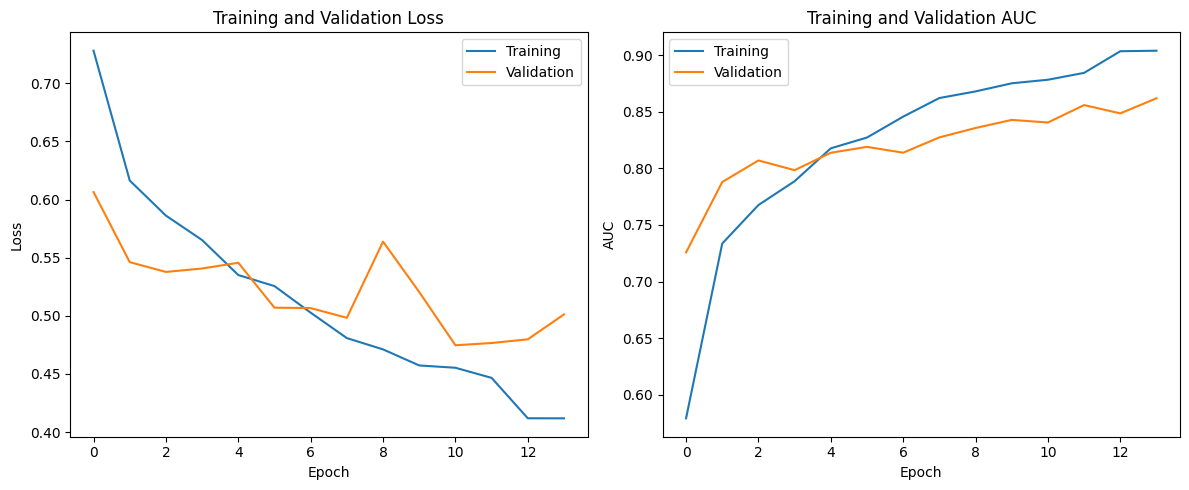

In [ ]:
plot_training_history(fusion_history)

### Validation Results

| Dataset / Model | Accuracy | Precision | Sensitivity | Specificity | F1 | AUC |
|---|---:|---:|---:|---:|---:|---:|
| Full Image – MobileNetV2 | 0.6070 | 0.5223 | 0.4141 | 0.7396 | 0.4620 | 0.6135 |
| Full Image – L2 + Dropout + Augmentation | 0.5885 | 0.4928 | 0.3434 | 0.7569 | 0.4048 | 0.6017 |
| Full Image – Weighted Class | 0.5864 | 0.4917 | 0.4495 | 0.6806 | 0.4697 | 0.6003 |
| Full Image – Fine-Tuned | 0.5679 | 0.4434 | 0.2374 | 0.7951 | 0.3092 | 0.6085 |
| ROI – MobileNetV2 | 0.6525 | 0.6438 | 0.5618 | 0.7310 | 0.6000 | 0.7093 |
| ROI – L2 + Dropout + Augmentation | 0.6617 | 0.6405 | 0.6175 | 0.7000 | 0.6288 | 0.6970 |
| ROI – Weighted Class | 0.6322 | 0.6066 | 0.5896 | 0.6690 | 0.5980 | 0.6955 |
| ROI – Fine-Tuned | 0.6525 | 0.6567 | 0.5259 | 0.7621 | 0.5841 | 0.7204 |
| **Full Image + ROI – Fusion** | **0.7704** | **0.6768** | **0.6537** | **0.8329** | **0.6650** | **0.8407** |


The feature-level fusion model achieved an accuracy of 0.7704 and an AUC of 0.8407, substantially exceeding the performance of the individual models. Compared with the strongest individual results, the fusion model improved accuracy by 10.87 percentage points and AUC by 12.03 percentage points. It also achieved higher sensitivity (65.37%) and specificity (83.29%) simultaneously, suggesting that combining full-image and ROI feature representations provided complementary information that improved overall classification performance.

In [ ]:
fusion_ft_model, fusion_ft_history, fusion_ft_results = run_8020_fusion_val(
    build_model=lambda: build_fusion_model(
        l2_val=1e-4,
        dropout_rate=0.5,
        use_augmentation=True,
        fine_tune_layers=20
    ),
    full_image_paths=fusion_full_paths,
    roi_image_paths=fusion_roi_paths,
    labels=fusion_labels,
    train_idx=fusion_train_idx,
    val_idx=fusion_val_idx,
    epochs=20,
    batch_size=32,
    learning_rate=1e-5,
    patience=3,
    use_class_weights=False
)


Class weighting: DISABLED

80/20 Fusion Train-Validation Split
Training images:   2276
Validation images: 588

Training class distribution
Benign: 1300
Malignant: 976

Validation class distribution
Benign: 383
Malignant: 205
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step - accuracy: 0.6037 - auc: 0.6403 - loss: 0.6944 - val_accuracy: 0.6922 - val_auc: 0.7437 - val_loss: 0.5853
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.6555 - auc: 0.7085 - loss: 0.6368 - val_accuracy: 0.7075 - val_auc: 0.7591 - val_loss: 0.5790
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.6841 - auc: 0.7537 - loss: 0.5997 - val_accuracy: 0.7109 - val_auc: 0.7727 - val_loss: 0.5631
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.6999 - auc: 0.7611 - loss: 0.5928 - val_accuracy: 0.7041 - val_auc: 0.7774 - val_loss: 0.5697
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.7122 - auc: 0.7914 - loss: 0.5662 - val_accuracy: 0.7007 - val_a

Performing Sanity Check for fine tuned fusion model, did not see much improvement in results while AUROC Dropped significantly, Moving on to evaluation with non-fine-tuned model.

In [ ]:
fusion_model.save("/content/drive/MyDrive/Models/DMS_fusion_model.keras")

According to Colab, the total training/validation time is 5 minutes

Create Test-Fusion Pairs

In [ ]:
test_full_lookup = {
    get_full_key(path): path
    for path in full_test_paths
}

test_full_index_lookup = {
    get_full_key(path): index
    for index, path in enumerate(full_test_paths)
}

test_fusion_full_paths = []
test_fusion_roi_paths = []
test_fusion_labels = []

unmatched_test = []

for roi_path, roi_label in zip(
    roi_test_paths,
    y_roi_test
):

    roi_key = get_roi_base_key(roi_path)

    if roi_key not in test_full_lookup:
        unmatched_test.append(roi_path)
        continue

    full_path = test_full_lookup[roi_key]

    test_fusion_full_paths.append(full_path)
    test_fusion_roi_paths.append(roi_path)
    test_fusion_labels.append(roi_label)


test_fusion_full_paths = np.array(test_fusion_full_paths)
test_fusion_roi_paths = np.array(test_fusion_roi_paths)

test_fusion_labels = np.array(
    test_fusion_labels,
    dtype=np.int32
)


print("TEST FUSION PAIRS")
print("=" * 50)

print("Total test fusion samples:",
      len(test_fusion_labels))

print("Benign:",
      np.sum(test_fusion_labels == 0))

print("Malignant:",
      np.sum(test_fusion_labels == 1))

print("Unmatched ROIs:",
      len(unmatched_test))

if unmatched_test:
    print("\nFirst unmatched test ROIs:")
    for path in unmatched_test[:20]:
        print(os.path.basename(path))


TEST FUSION PAIRS
Total test fusion samples: 401
Benign: 240
Malignant: 161
Unmatched ROIs: 146

First unmatched test ROIs:
Calc_P_00038_LEFT_CC_1.png
Calc_P_00038_RIGHT_CC_1.png
Calc_P_00038_RIGHT_CC_2.png
Calc_P_00041_LEFT_CC_2.png
Calc_P_00041_LEFT_MLO_2.png
Calc_P_00077_LEFT_MLO_1.png
Calc_P_00077_RIGHT_CC_1.png
Calc_P_00077_RIGHT_MLO_1.png
Calc_P_00140_LEFT_CC_1.png
Calc_P_00140_LEFT_CC_2.png
Calc_P_00140_LEFT_MLO_2.png
Calc_P_00140_RIGHT_CC_1.png
Calc_P_00140_RIGHT_MLO_1.png
Calc_P_00163_LEFT_CC_1.png
Calc_P_00180_LEFT_CC_1.png
Calc_P_00214_LEFT_CC_1.png
Calc_P_00214_LEFT_MLO_1.png
Calc_P_00214_LEFT_MLO_2.png
Calc_P_00214_RIGHT_MLO_1.png
Calc_P_00257_RIGHT_CC_1.png


Create Test Dataset

In [ ]:
def create_fusion_test_dataset(
    full_paths,
    roi_paths,
    labels,
    batch_size=32
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "full_input": full_paths,
                "roi_input": roi_paths
            },
            labels
        )
    )

    def load_fusion_images(inputs, label):

        # ----------------------------------------------------
        # Full mammogram
        # ----------------------------------------------------

        full_image_bytes = tf.io.read_file(
            inputs["full_input"]
        )

        full_image = tf.image.decode_png(
            full_image_bytes,
            channels=3
        )

        full_image = tf.image.resize(
            full_image,
            IMG_SIZE
        )

        full_image = tf.cast(
            full_image,
            tf.float32
        )

        full_image = (
            tf.keras.applications.mobilenet_v2
            .preprocess_input(full_image)
        )

        # ----------------------------------------------------
        # ROI
        # ----------------------------------------------------

        roi_image_bytes = tf.io.read_file(
            inputs["roi_input"]
        )

        roi_image = tf.image.decode_png(
            roi_image_bytes,
            channels=3
        )

        roi_image = tf.image.resize(
            roi_image,
            IMG_SIZE
        )

        roi_image = tf.cast(
            roi_image,
            tf.float32
        )

        roi_image = (
            tf.keras.applications.mobilenet_v2
            .preprocess_input(roi_image)
        )

        return {
            "full_input": full_image,
            "roi_input": roi_image
        }, label

    dataset = dataset.map(
        load_fusion_images,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


test_fusion_ds = create_fusion_test_dataset(
    test_fusion_full_paths,
    test_fusion_roi_paths,
    test_fusion_labels,
    batch_size=32
)

print("Test dataset created.")


Test dataset created.


In [ ]:

final_model = keras.models.load_model(
    "/content/drive/MyDrive/Models/DMS_fusion_model.keras"
)

In [ ]:
# TEST PREDICTIONS

y_test_true = test_fusion_labels

y_test_prob = final_model.predict(
    test_fusion_ds,
    verbose=1
).ravel()

print("Number of predictions:",
      len(y_test_prob))

print("Number of labels:",
      len(y_test_true))

assert len(y_test_prob) == len(y_test_true)


13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step
Number of predictions: 401
Number of labels: 401


In [ ]:
# TEST CLASSIFICATION

THRESHOLD = 0.5

y_test_pred = (
    y_test_prob >= THRESHOLD
).astype(int)


In [ ]:
# CONFUSION MATRIX

tn, fp, fn, tp = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1]
).ravel()

print("Confusion Matrix")
print("=" * 40)

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


Confusion Matrix
TN: 177
FP: 63
FN: 54
TP: 107


In [ ]:
# FINAL TEST METRICS

def calculate_test_metrics(
    y_true,
    y_prob,
    threshold=0.5
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    false_negatives_per_1000 = (
        false_negative_rate * 1000
    )

    metrics = {
        "threshold": threshold,

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "false_negative_rate":
            false_negative_rate,

        "false_negatives_per_1000":
            false_negatives_per_1000,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    return metrics


test_results = calculate_test_metrics(
    y_true=y_test_true,
    y_prob=y_test_prob,
    threshold=0.5
)

print("\nFINAL TEST RESULTS")
print("=" * 50)

print(
    f"Accuracy:              "
    f"{test_results['accuracy']:.4f}"
)

print(
    f"Precision:             "
    f"{test_results['precision']:.4f}"
)

print(
    f"Sensitivity:           "
    f"{test_results['sensitivity']:.4f}"
)

print(
    f"Specificity:           "
    f"{test_results['specificity']:.4f}"
)

print(
    f"F1 Score:              "
    f"{test_results['f1']:.4f}"
)

print(
    f"AUC:                   "
    f"{test_results['auc']:.4f}"
)

print(
    f"False Negative Rate:   "
    f"{test_results['false_negative_rate']:.4f}"
)

print(
    f"False Negatives/1000:  "
    f"{test_results['false_negatives_per_1000']:.2f}"
)

print("\nConfusion Matrix")
print(
    f"TN={test_results['tn']}  "
    f"FP={test_results['fp']}  "
    f"FN={test_results['fn']}  "
    f"TP={test_results['tp']}"
)



FINAL TEST RESULTS
Accuracy:              0.7082
Precision:             0.6294
Sensitivity:           0.6646
Specificity:           0.7375
F1 Score:              0.6465
AUC:                   0.7943
False Negative Rate:   0.3354
False Negatives/1000:  335.40

Confusion Matrix
TN=177  FP=63  FN=54  TP=107


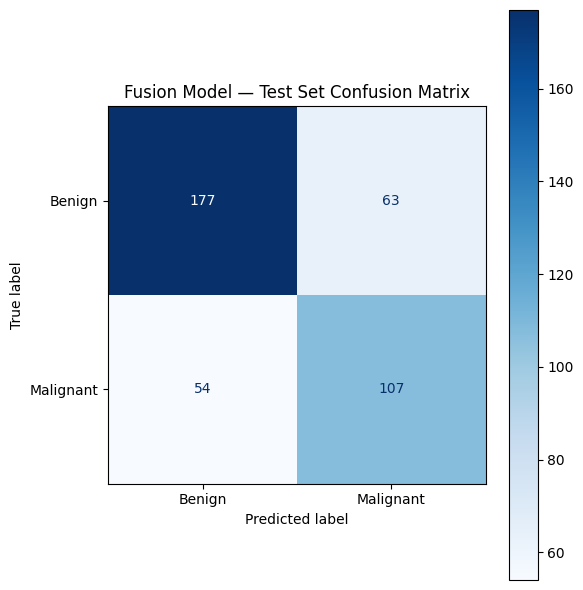

In [ ]:
# CONFUSION MATRIX PLOT

cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(
    "Fusion Model — Test Set Confusion Matrix"
)

plt.tight_layout()
plt.show()


In [ ]:
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)


              precision    recall  f1-score   support

      Benign     0.7662    0.7375    0.7516       240
   Malignant     0.6294    0.6646    0.6465       161

    accuracy                         0.7082       401
   macro avg     0.6978    0.7010    0.6991       401
weighted avg     0.7113    0.7082    0.7094       401

